In [1]:
from process_signals import *
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import os

import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='The test statistic is outside of the range of p-values')
warnings.filterwarnings('ignore', category=UserWarning, message='No frequency information was provided, so inferred frequency D will be used.')

/home/iann/Desktop/Risk/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
if not os.path.exists('img'):
    os.makedirs('img')

In [3]:
data = pd.read_csv('./data/consumo.csv', encoding="utf-8", thousands=".", decimal=",")
print(data.shape)
data.head(7)

(3073, 15)


,AÑO,MES,Fecha,Tipo día,GRAN BS.AS.,BUENOS AIRES,CENTRO,LITORAL,CUYO,NOROESTE,NORESTE,COMAHUE,PATAGONICA,DEMANDA TOTAL,TEMPERATURA REFERENCIA MEDIA GBA °C
0,2017,ene-17,1/1/2017,Domingo o Feriado,6352.7,1472.3,1134.4,1766.6,903.1,1602.1,1400.3,561.2,500.9,15693.7,31.3
1,2017,ene-17,2/1/2017,Lunes habiles,6617.9,1779.4,1363.5,1963.9,1091.8,1627.6,1585.6,638.8,540.6,17209.2,25.4
2,2017,ene-17,3/1/2017,Martes Habiles,6678.0,1889.0,1600.7,2036.3,1178.7,1806.5,1653.0,624.6,536.5,18003.4,25.5
3,2017,ene-17,4/1/2017,Miercoles habiles,6427.0,1840.6,1356.4,1756.6,1078.9,1759.9,1604.8,598.4,528.9,16951.5,27.0
4,2017,ene-17,5/1/2017,Jueves Habiles,5874.0,1770.9,1366.0,1848.4,1037.8,1403.5,1228.3,585.2,524.7,15638.8,21.9
5,2017,ene-17,6/1/2017,Viernes habiles,5781.1,1801.1,1367.4,1929.8,1135.5,1354.6,1218.7,615.5,550.9,15754.5,24.3
6,2017,ene-17,7/1/2017,Sabado o Semilaborable,6231.7,1862.7,1388.8,2042.9,1161.9,1425.7,1306.4,626.4,533.9,16580.5,29.1


In [4]:
data['Fecha'] = pd.to_datetime(data['Fecha'], format='%d/%m/%Y')
data.set_index('Fecha', inplace=True)

# Verificación de datos nulos o faltantes

In [5]:
print(data.isnull().sum())
print('Datos totales', data.shape[0])
print('Cantidad de días', (data.index[-1] - data.index[0]).days)

AÑO                                    0
MES                                    0
Tipo día                               0
GRAN BS.AS.                            0
BUENOS AIRES                           0
CENTRO                                 0
LITORAL                                0
CUYO                                   0
NOROESTE                               0
NORESTE                                0
COMAHUE                                0
PATAGONICA                             0
DEMANDA TOTAL                          0
TEMPERATURA REFERENCIA MEDIA GBA °C    0
dtype: int64
Datos totales 3073
Cantidad de días 3072


In [6]:
# Separamos todas las series de tiempo
apodos = ['GBA', 'BSAS', 'CENTRO', 'LITORAL', 'CUYO', 'NOESTE', 'NESTE', 'COMAHUE', 'PATAG', 'TOTAL']
colores = {
    'GRAN BS.AS.':'tab:blue',
    'BUENOS AIRES':'tab:orange',
    'CENTRO':'tab:green',
    'LITORAL':'tab:red',
    'CUYO':'tab:purple',
    'NOROESTE':'tab:brown',
    'NORESTE':'tab:pink',
    'COMAHUE':'tab:gray',
    'PATAGONICA':'tab:olive',
    'DEMANDA TOTAL': 'tab:cyan',
}
series = {}
for col in ['GRAN BS.AS.','BUENOS AIRES','CENTRO','LITORAL','CUYO','NOROESTE','NORESTE','COMAHUE','PATAGONICA','DEMANDA TOTAL']:
    series[col] = {}
    series[col]['ORIGINAL'] = data[col].dropna()
    series[col]['APODO'] = apodos.pop(0)

# Trabajar sólo con la serie de DEMANDA TOTAL:
# series = {}
# series['DEMANDA TOTAL'] = {}
# series['DEMANDA TOTAL']['ORIGINAL'] = data['DEMANDA TOTAL'].dropna()
# series['DEMANDA TOTAL']['APODO'] = 'TOTAL'

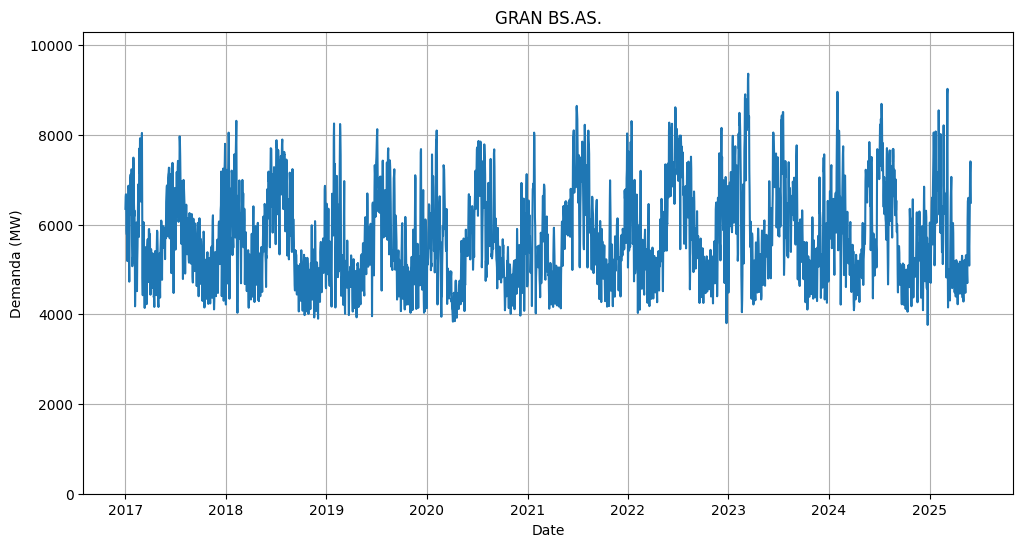

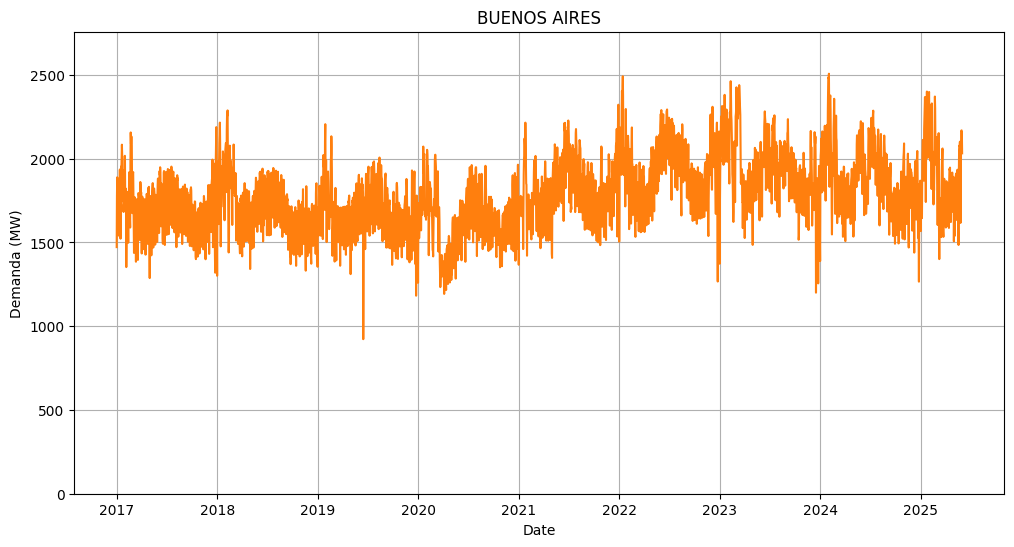

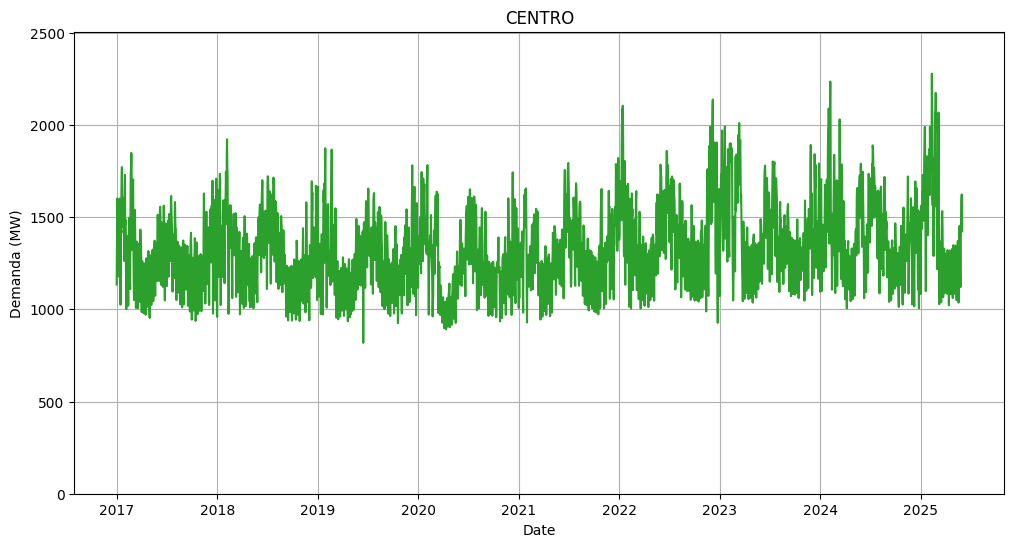

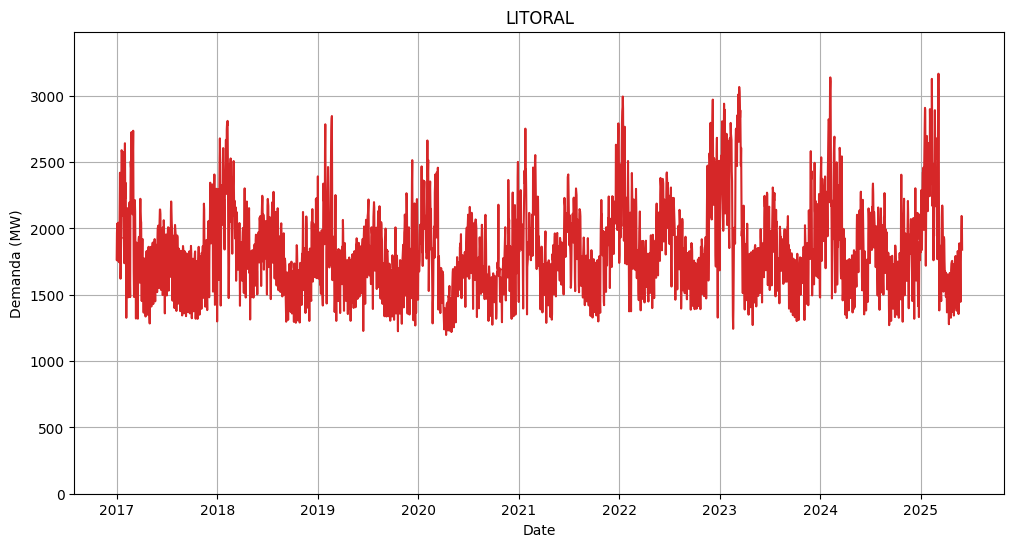

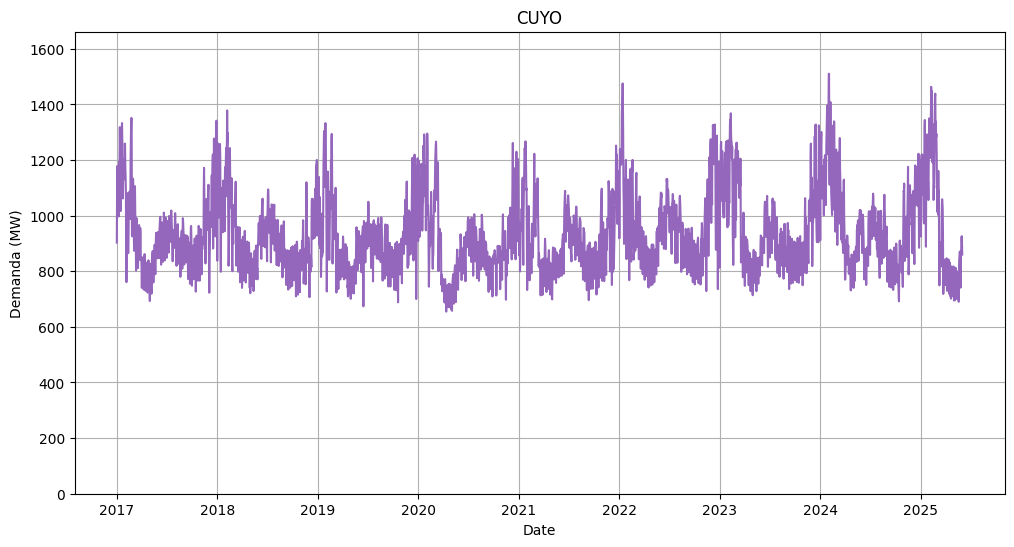

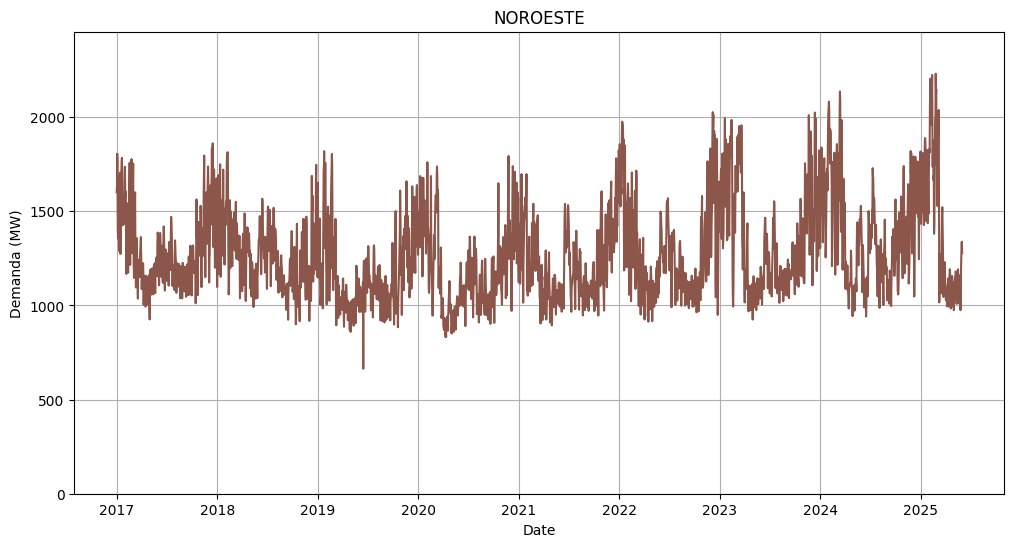

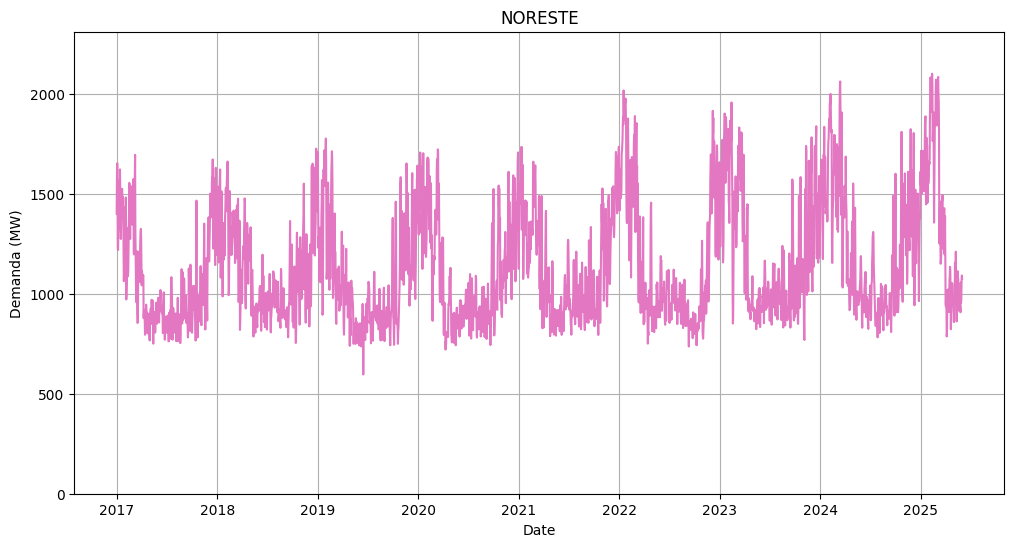

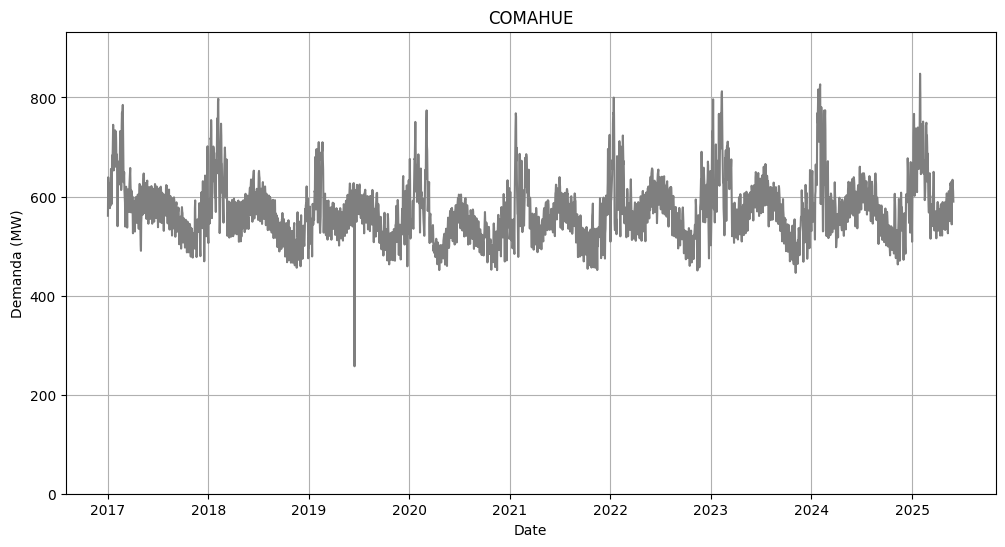

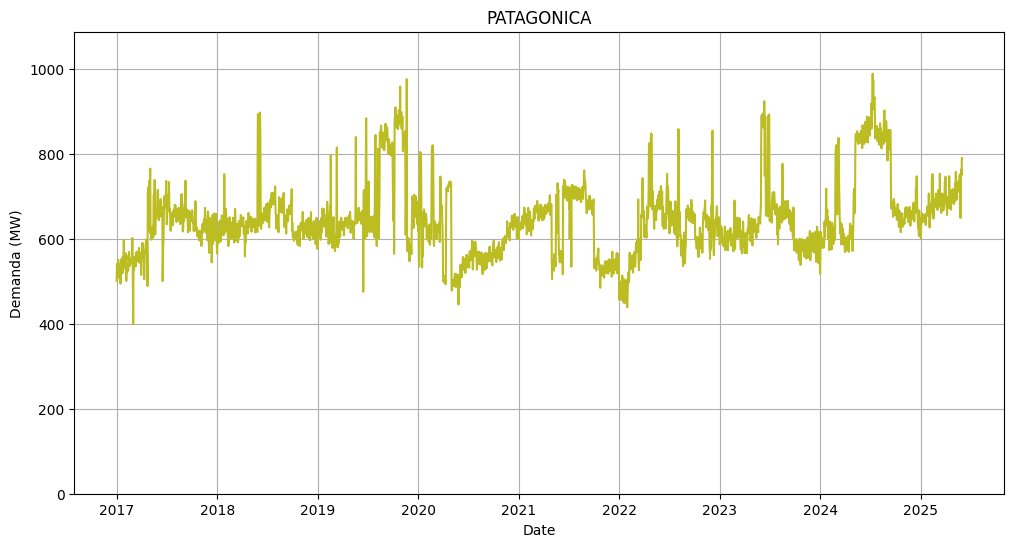

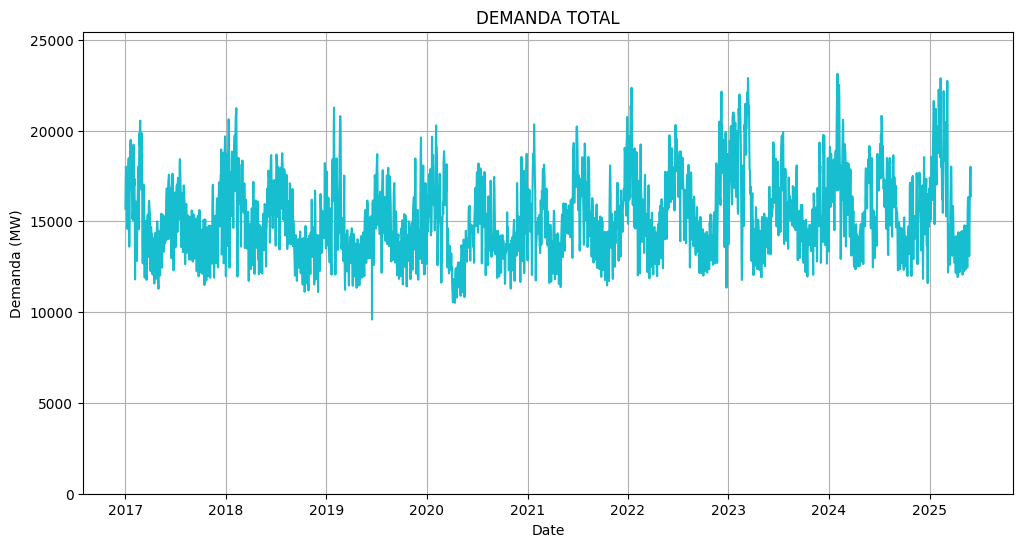

In [7]:
# Plot series
ymin = 0
for col, serie in series.items():
    ymax = serie['ORIGINAL'].max() * 1.1
    plot_series(serie['ORIGINAL'], color=colores[col], title=col, ymin=ymin, ymax=ymax)

### El pico bajo de demanda durante la fecha 16/06/2019 corresponde al "apagón del siglo"

In [8]:
# Ubicamos el pico bajo de demanda
idxmindata = series['DEMANDA TOTAL']['ORIGINAL'].idxmin().date()
print(f"Fecha del pico bajo de demanda: {idxmindata}")
# Causa: "Apagón del siglo"

Fecha del pico bajo de demanda: 2019-06-16


# Filtros de Media movil.
### Trabajamos con MA30 para obtener mejores resultados

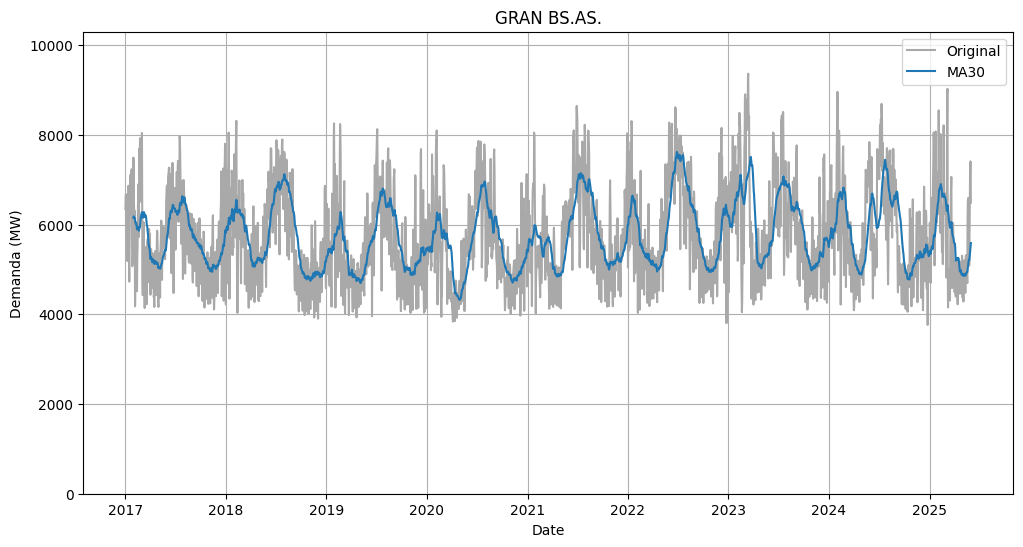

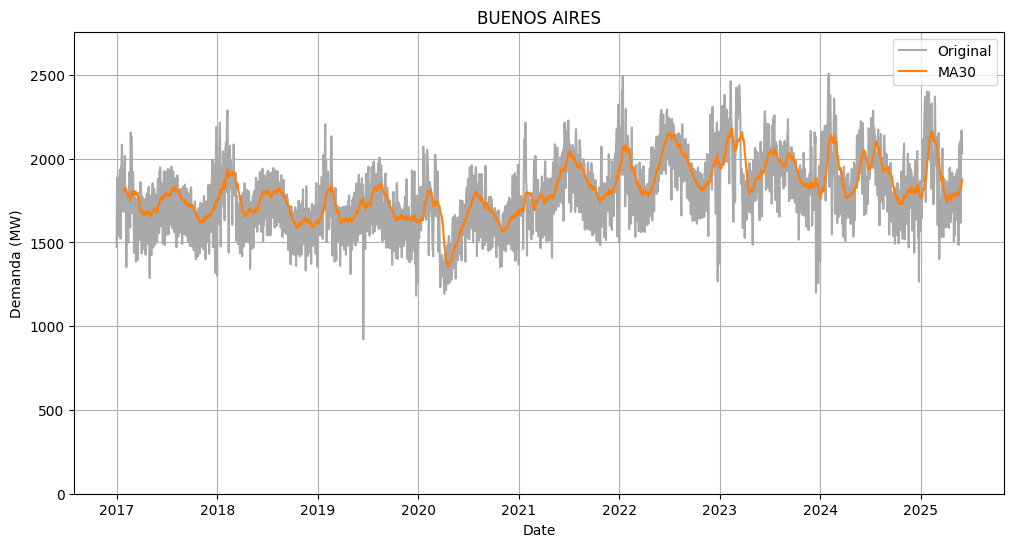

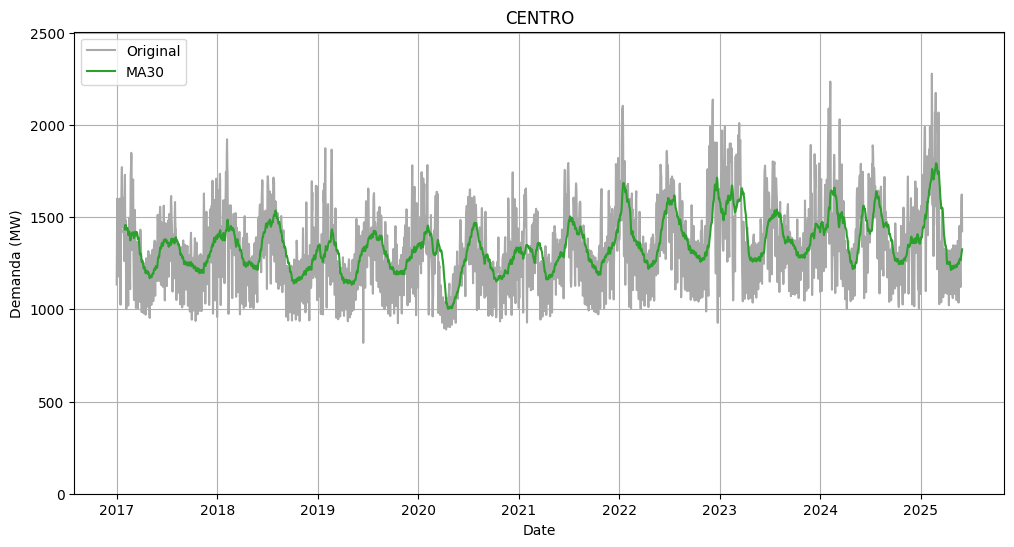

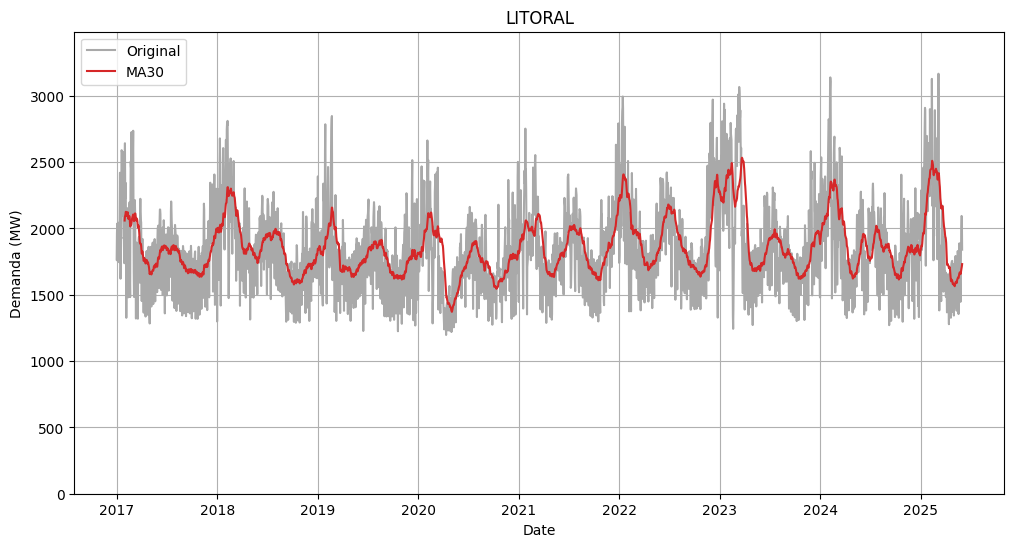

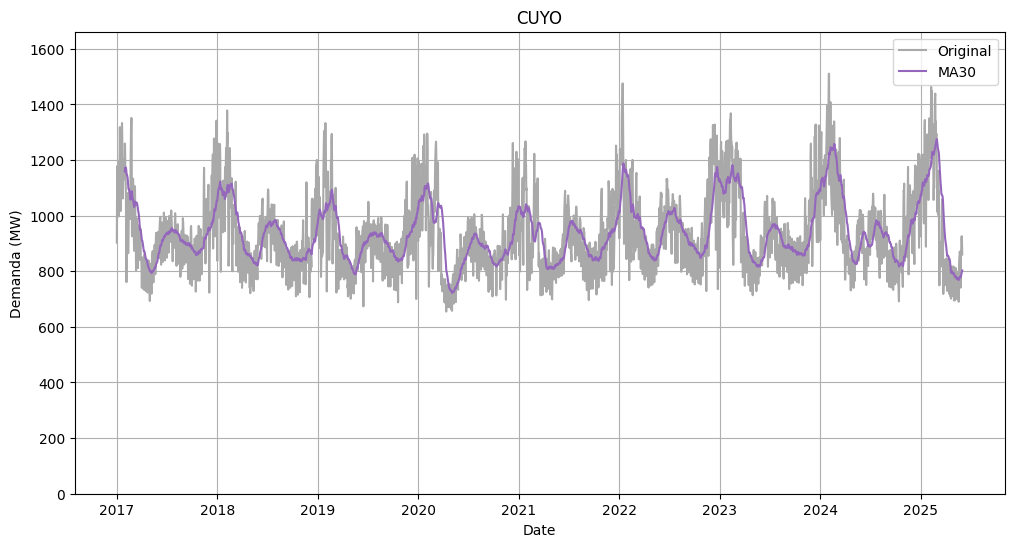

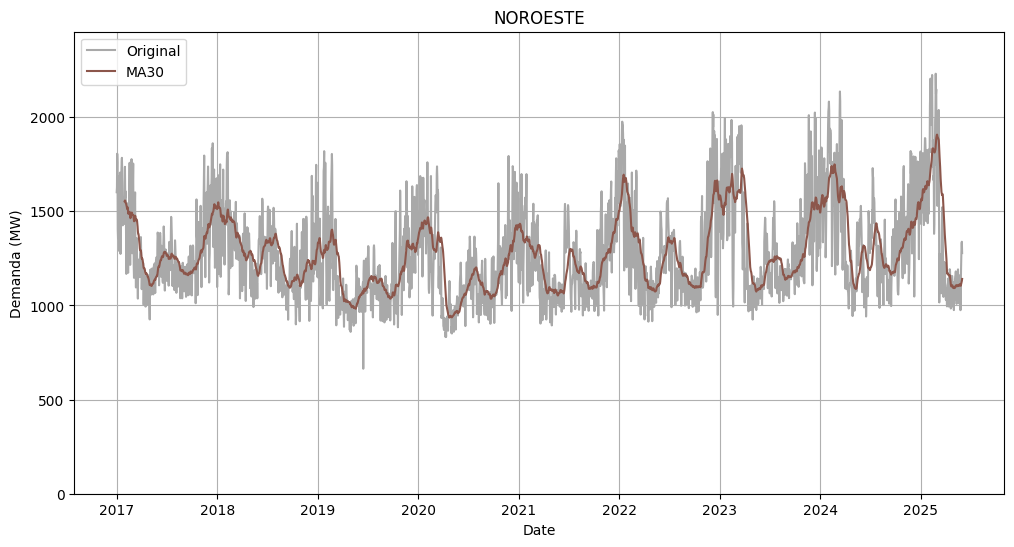

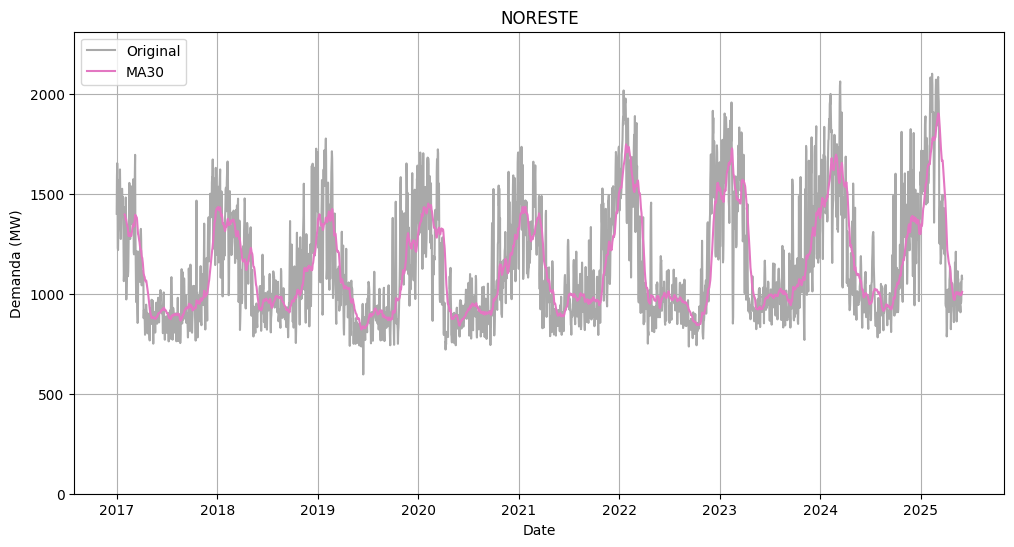

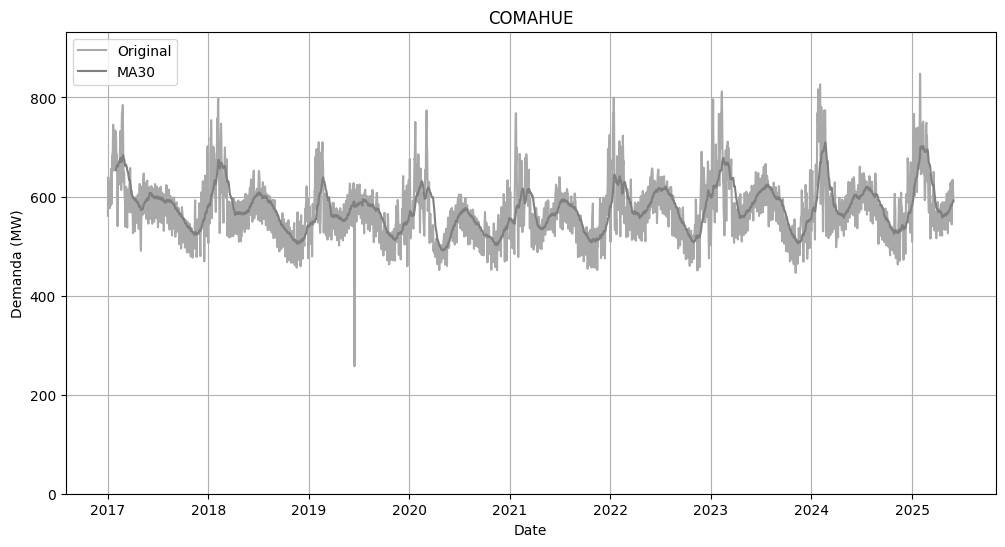

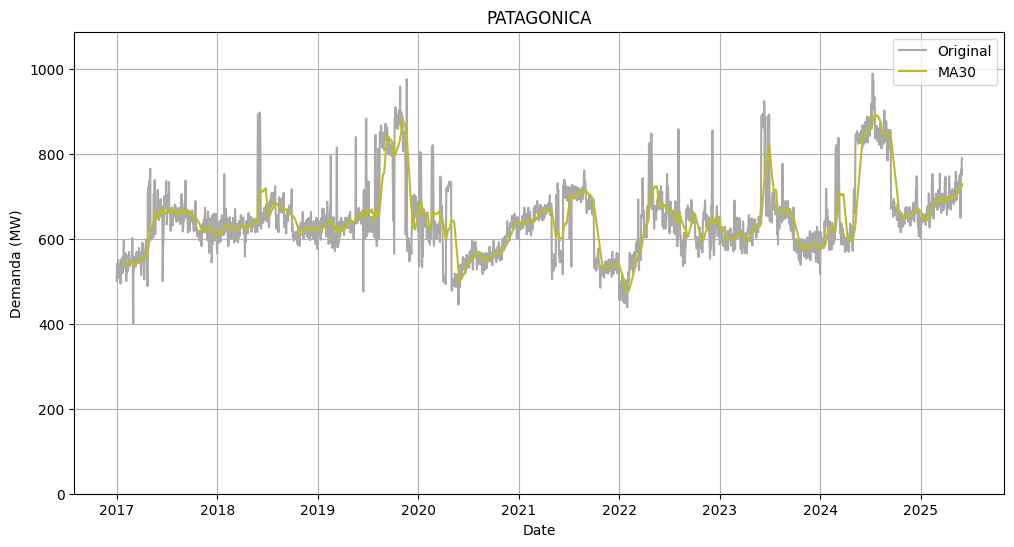

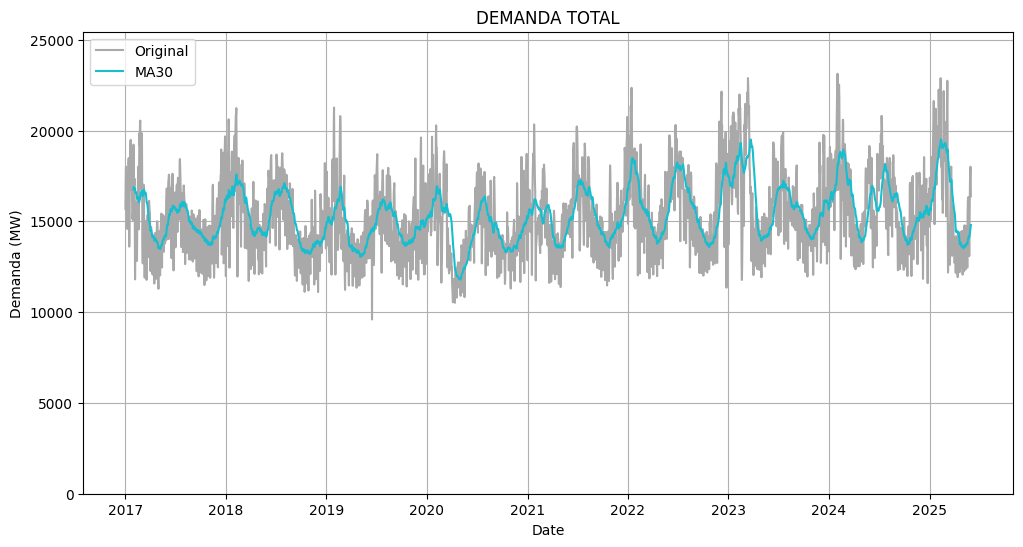

In [9]:
# Agregamos columna de Moving Average (MA30)
for col, serie in series.items():
    serie['MA30'] = moving_average(serie['ORIGINAL'], 30)
    plot_moving_average(serie['ORIGINAL'], serie['MA30'], color=colores[col], window=30, title=col, ymin=0, ymax=serie['ORIGINAL'].max() * 1.1)

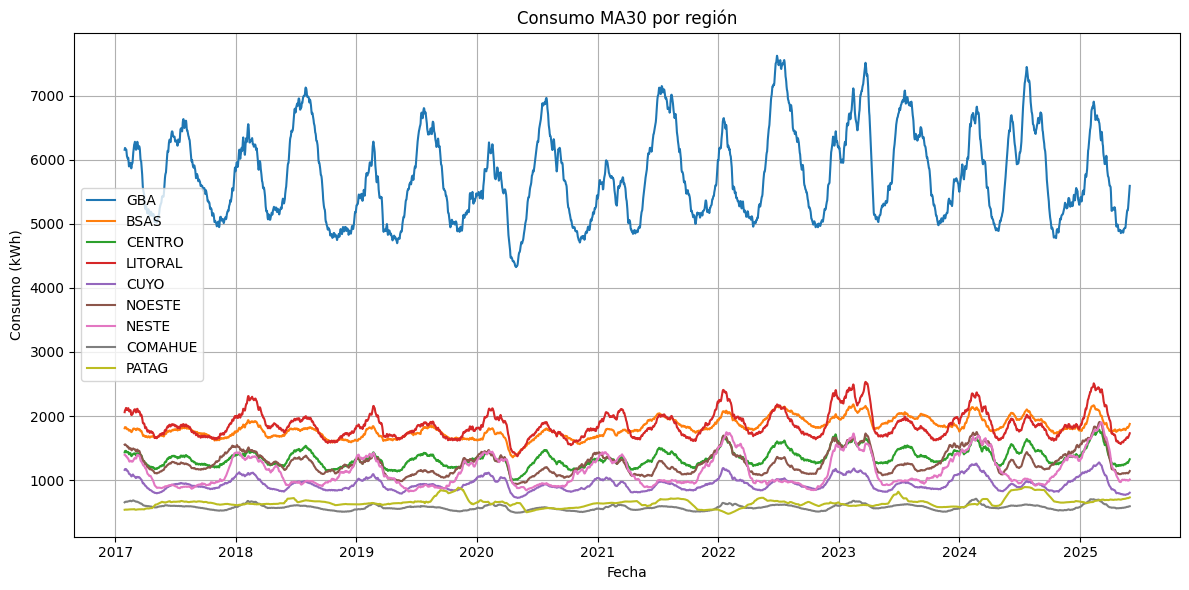

In [10]:
# Graficamos el consumo MA30 por región (todas las regiones)
plt.figure(figsize=(12, 6))
for col, serie in series.items():
    if col != 'DEMANDA TOTAL': # and col != 'GRAN BS.AS.':
        plt.plot(serie['MA30'], color=colores[col], label=serie['APODO'])
plt.title('Consumo MA30 por región')
plt.xlabel('Fecha')
plt.ylabel('Consumo (kWh)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig('img/consumo_ma30_por_region.png', dpi=300, bbox_inches='tight')
plt.show()

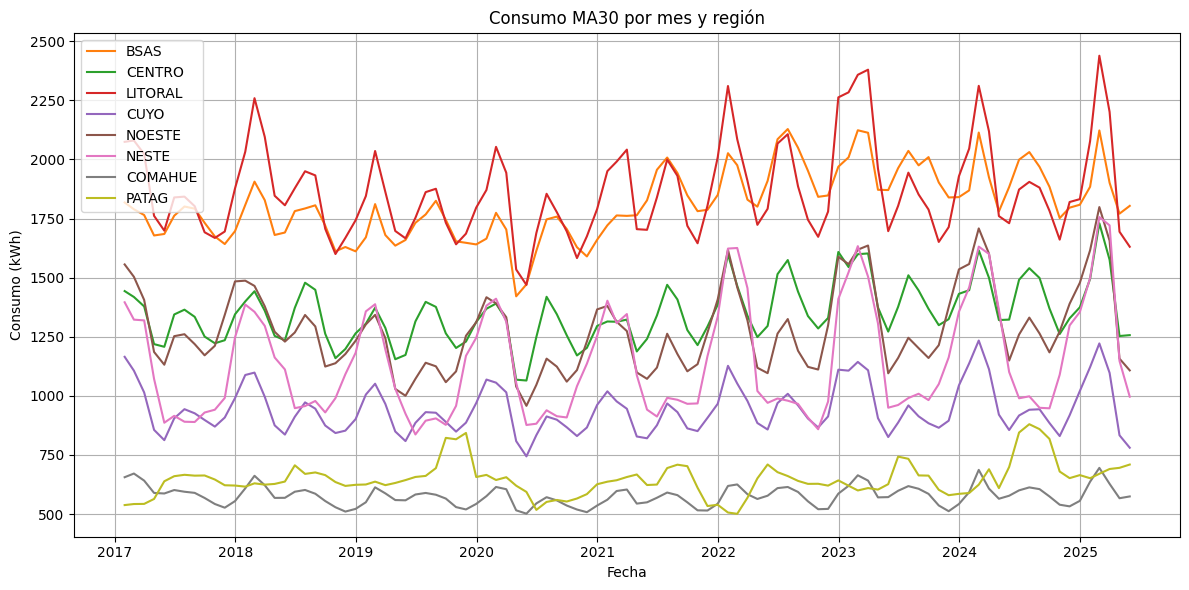

In [11]:
# Serie MA30 agrupada por mes de cada región:
for col, serie in series.items():
    serie['MES'] = serie['MA30'].resample('ME').mean()

# Gráfico en función del mes de cada región exceptuando GRAN BS.AS (AMBA).
plt.figure(figsize=(12, 6))
for col, serie in series.items():
    if col != 'DEMANDA TOTAL' and col != 'GRAN BS.AS.':
        plt.plot(serie['MES'], color=colores[col], label=serie['APODO'])
plt.title('Consumo MA30 por mes y región')
plt.xlabel('Fecha')
plt.ylabel('Consumo (kWh)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig('img/consumo_ma30_mes.png', dpi=300, bbox_inches='tight')
plt.show()

# Test de estacionalidad
### Utilizamos ADF y KPSS

In [12]:
for col, serie in series.items():
    serie['SEASONALITY'] = seasonality_tests(serie['ORIGINAL'])
    print_stationarity_tests(results=serie['SEASONALITY'], name=serie['APODO'])
    print('-----------------------------------------------------------')

[ADF](0.00)		GBA		Es estacionaria
[KPSS](0.10)		GBA		Es estacionaria
-----------------------------------------------------------
[ADF](0.00)		BSAS		Es estacionaria
[KPSS](0.01)		BSAS		No es estacionaria
-----------------------------------------------------------
[ADF](0.00)		CENTRO		Es estacionaria
[KPSS](0.01)		CENTRO		No es estacionaria
-----------------------------------------------------------
[ADF](0.00)		LITORAL		Es estacionaria
[KPSS](0.04)		LITORAL		No es estacionaria
-----------------------------------------------------------
[ADF](0.00)		CUYO		Es estacionaria
[KPSS](0.10)		CUYO		Es estacionaria
-----------------------------------------------------------
[ADF](0.00)		NOESTE		Es estacionaria
[KPSS](0.01)		NOESTE		No es estacionaria
-----------------------------------------------------------
[ADF](0.00)		NESTE		Es estacionaria
[KPSS](0.02)		NESTE		No es estacionaria
-----------------------------------------------------------
[ADF](0.00)		COMAHUE		Es estacionaria
[KPSS](0.06)		CO

# Parcialmente estacionaria

### ADF siempre marca estacionaria, y en ciertas regiones KPSS discrepa.

## La naturaleza de los datos es estacionaria, por lo que trabajamos con la serie así como está.

### También podemos aplicarle diferenciación para hacerla estacionaria:

In [13]:
for col, serie in series.items():
    serie['DIFF'] = differentiate(serie['ORIGINAL'])
    serie['DIFF_SEASONALITY'] = seasonality_tests(serie['DIFF'])
    print_stationarity_tests(results=serie['DIFF_SEASONALITY'], name=serie['APODO'])
    print('-----------------------------------------------------------')

[ADF](0.00)		GBA		Es estacionaria
[KPSS](0.10)		GBA		Es estacionaria
-----------------------------------------------------------
[ADF](0.00)		BSAS		Es estacionaria
[KPSS](0.10)		BSAS		Es estacionaria
-----------------------------------------------------------
[ADF](0.00)		CENTRO		Es estacionaria
[KPSS](0.10)		CENTRO		Es estacionaria
-----------------------------------------------------------
[ADF](0.00)		LITORAL		Es estacionaria
[KPSS](0.10)		LITORAL		Es estacionaria
-----------------------------------------------------------
[ADF](0.00)		CUYO		Es estacionaria
[KPSS](0.10)		CUYO		Es estacionaria
-----------------------------------------------------------
[ADF](0.00)		NOESTE		Es estacionaria
[KPSS](0.10)		NOESTE		Es estacionaria
-----------------------------------------------------------
[ADF](0.00)		NESTE		Es estacionaria
[KPSS](0.10)		NESTE		Es estacionaria
-----------------------------------------------------------
[ADF](0.00)		COMAHUE		Es estacionaria
[KPSS](0.10)		COMAHUE		Es estac

# Visualización de series diferenciadas y sus autocorrelaciones

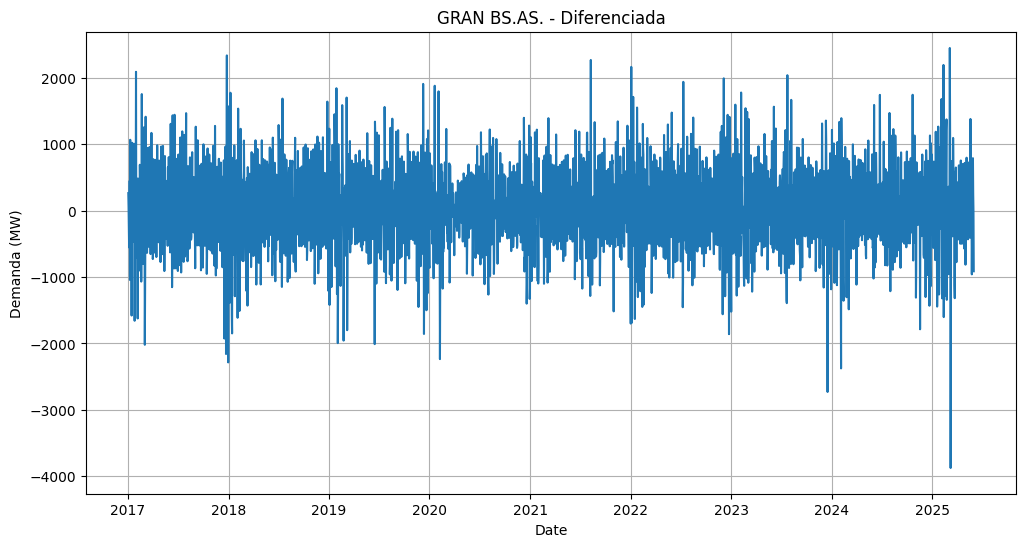

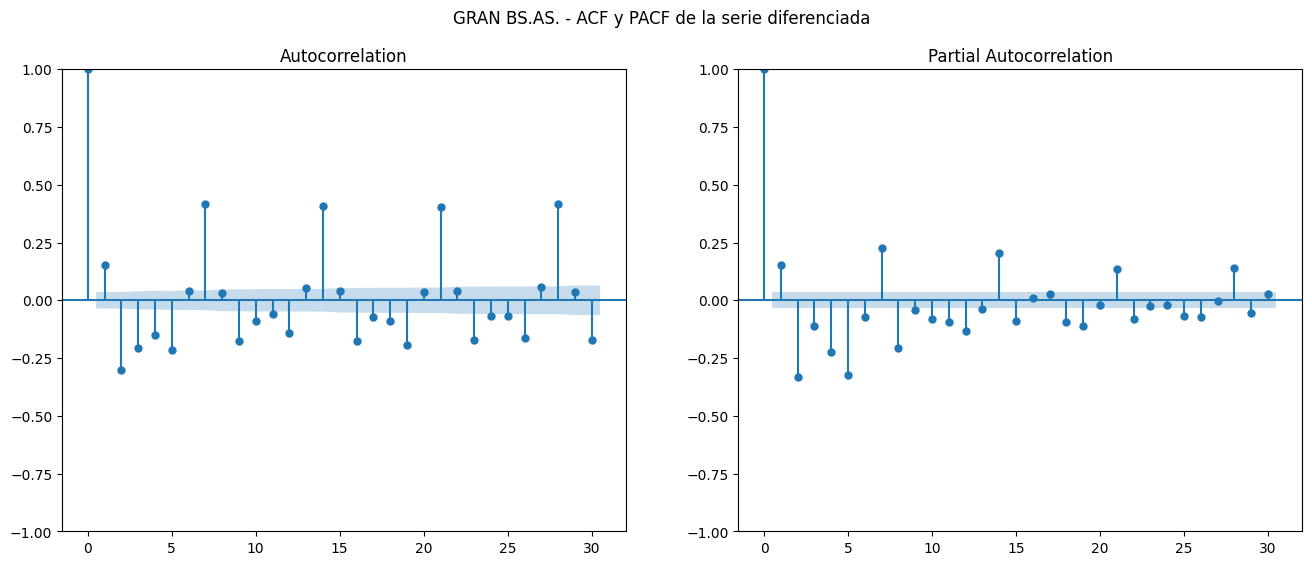

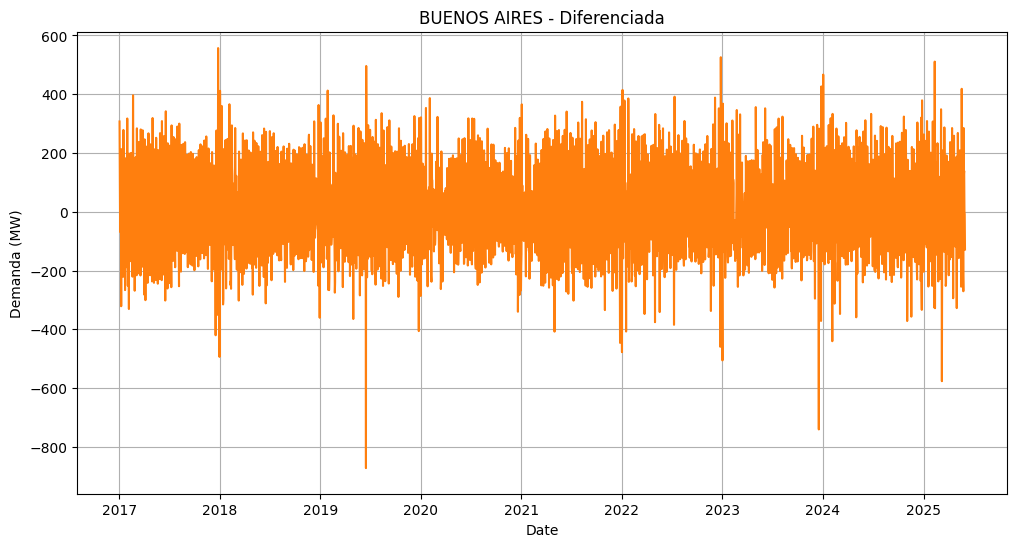

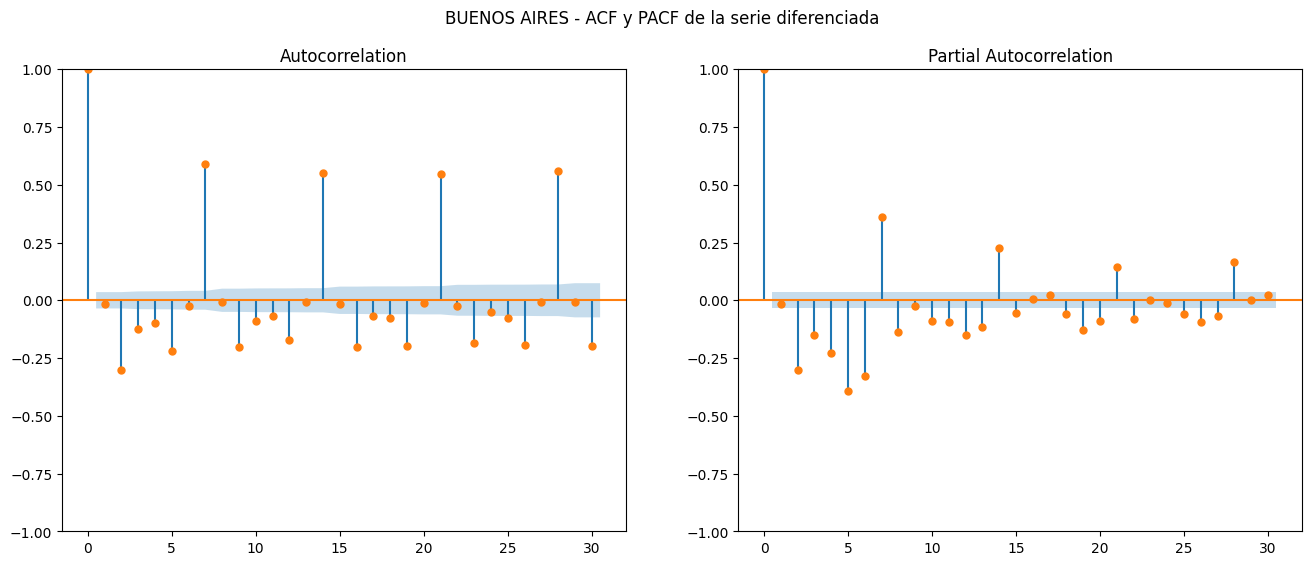

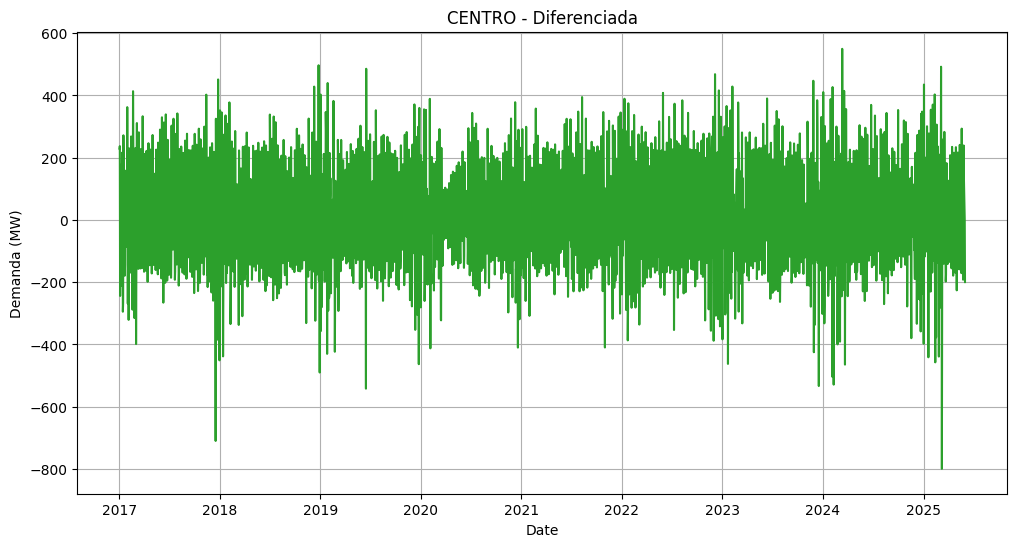

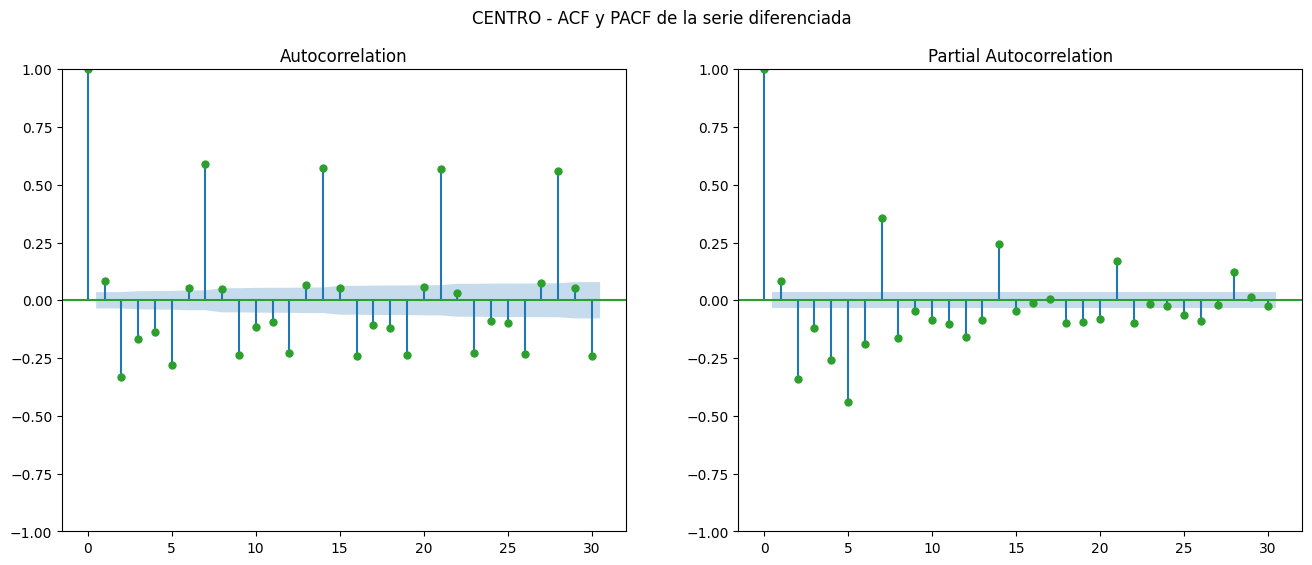

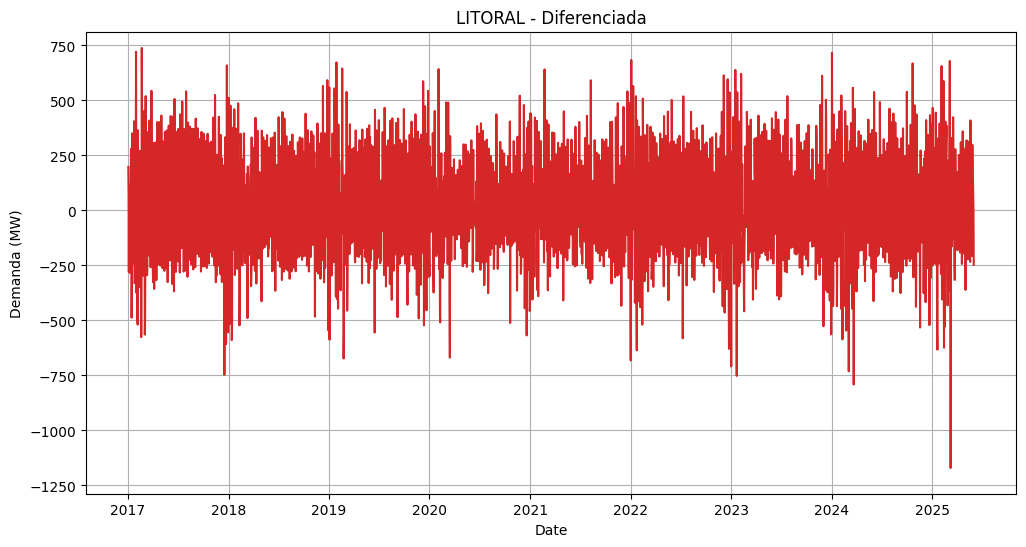

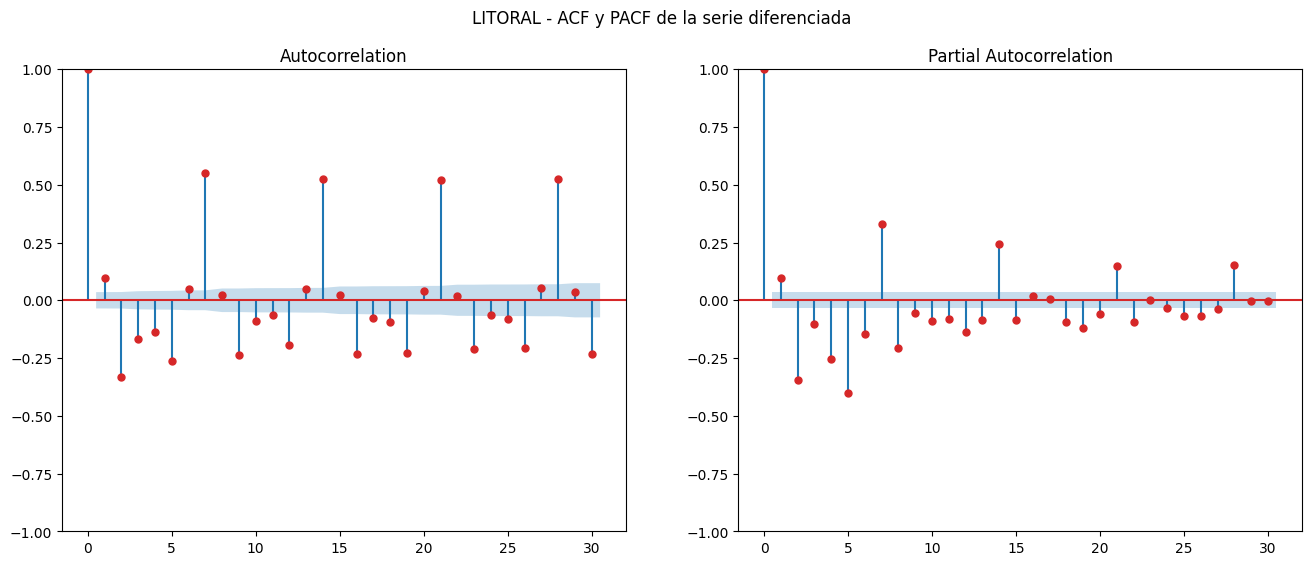

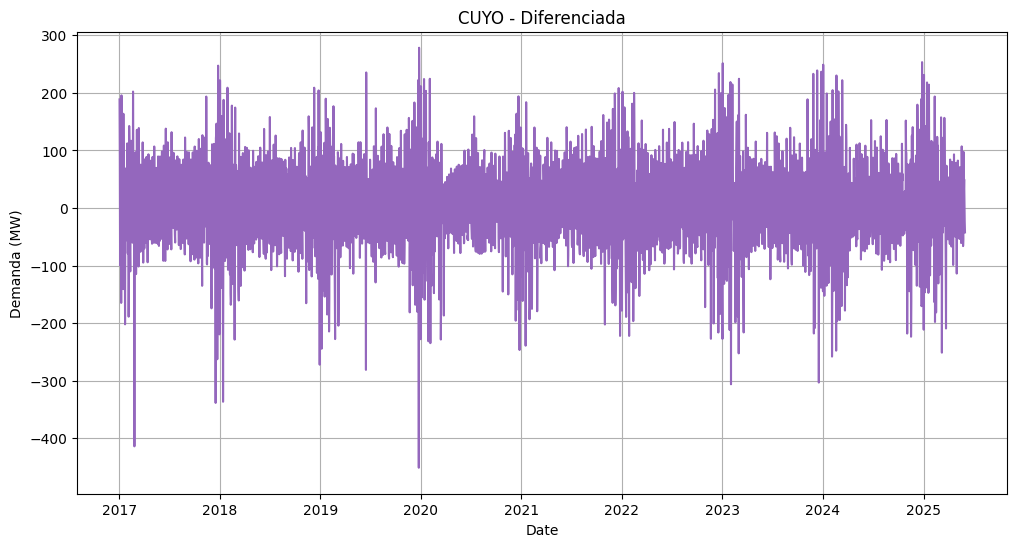

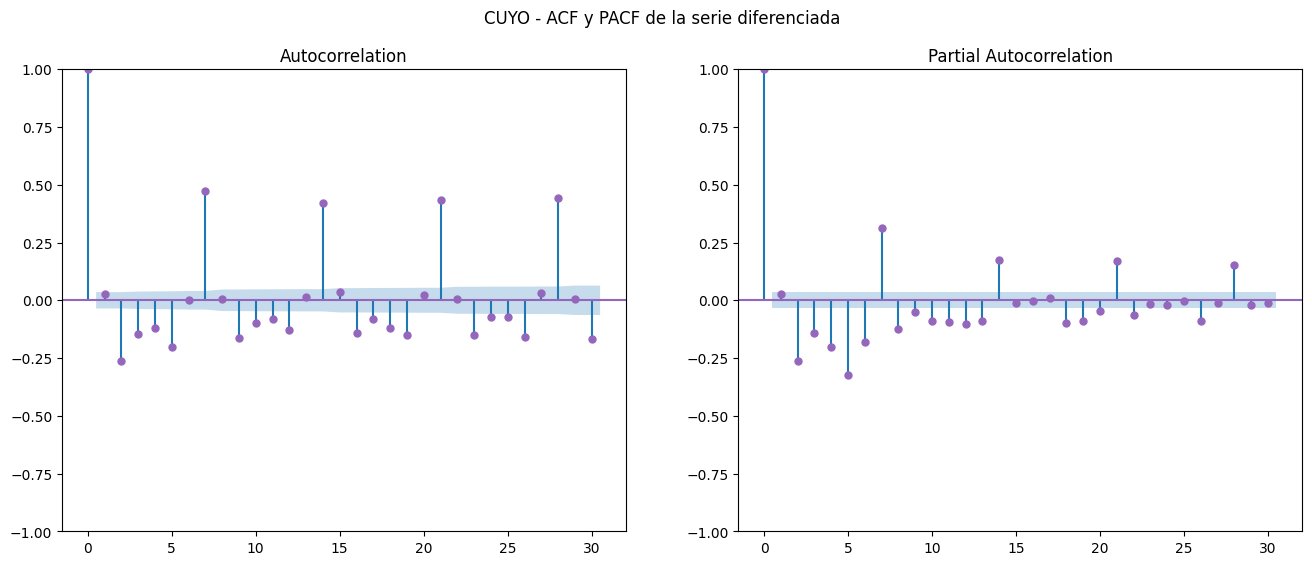

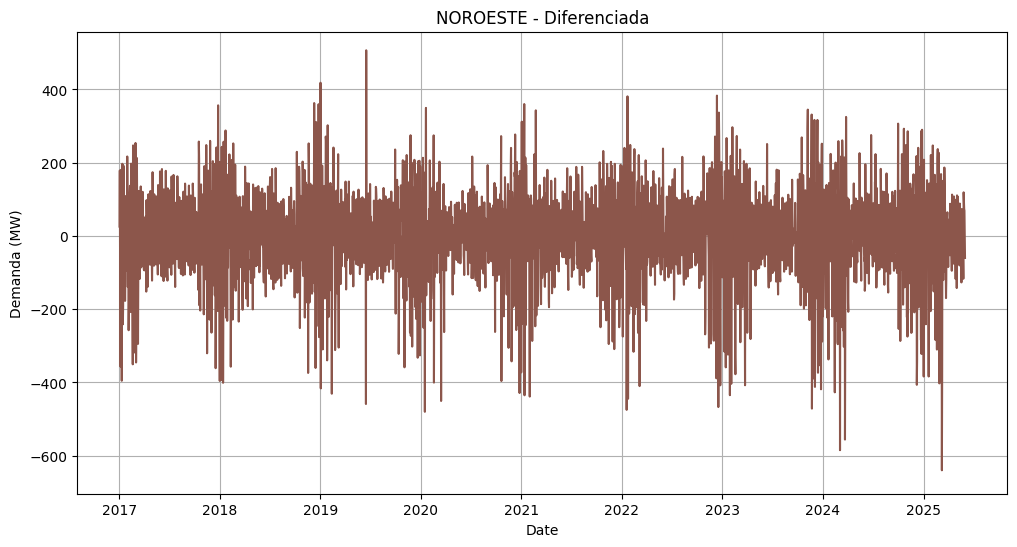

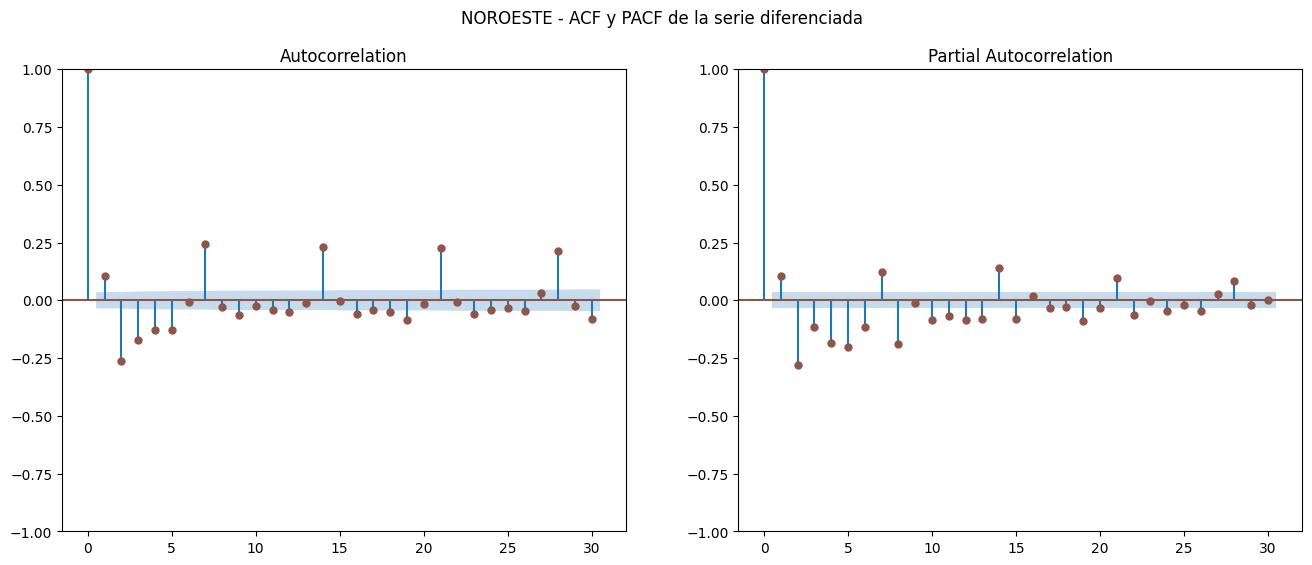

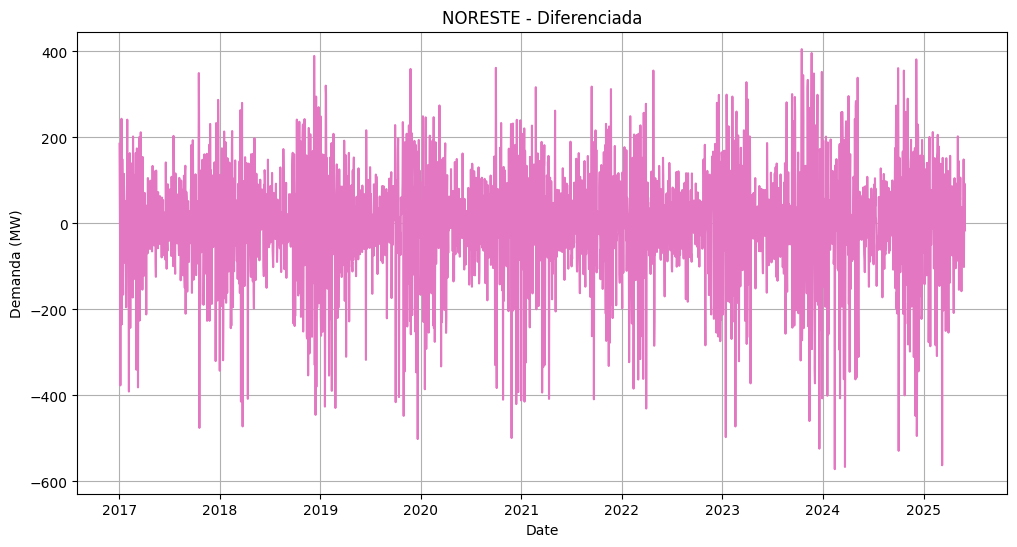

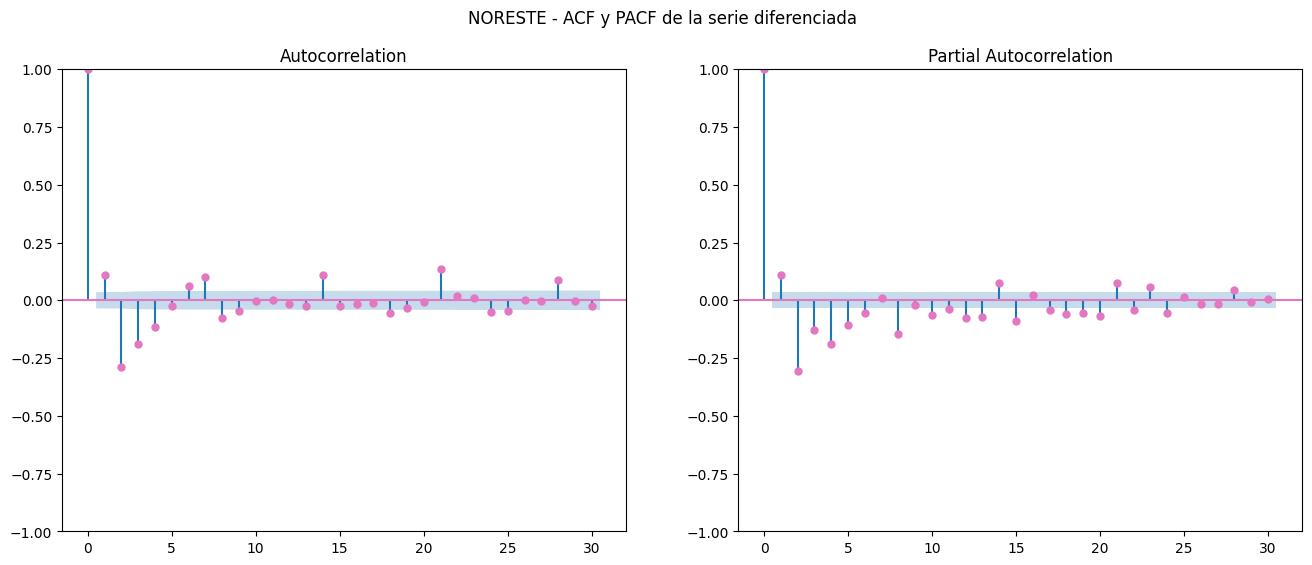

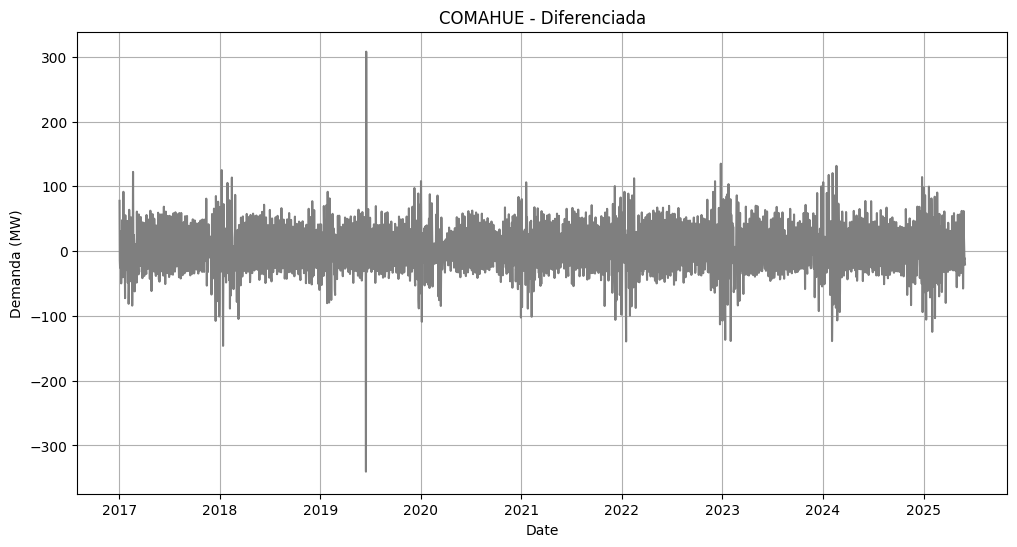

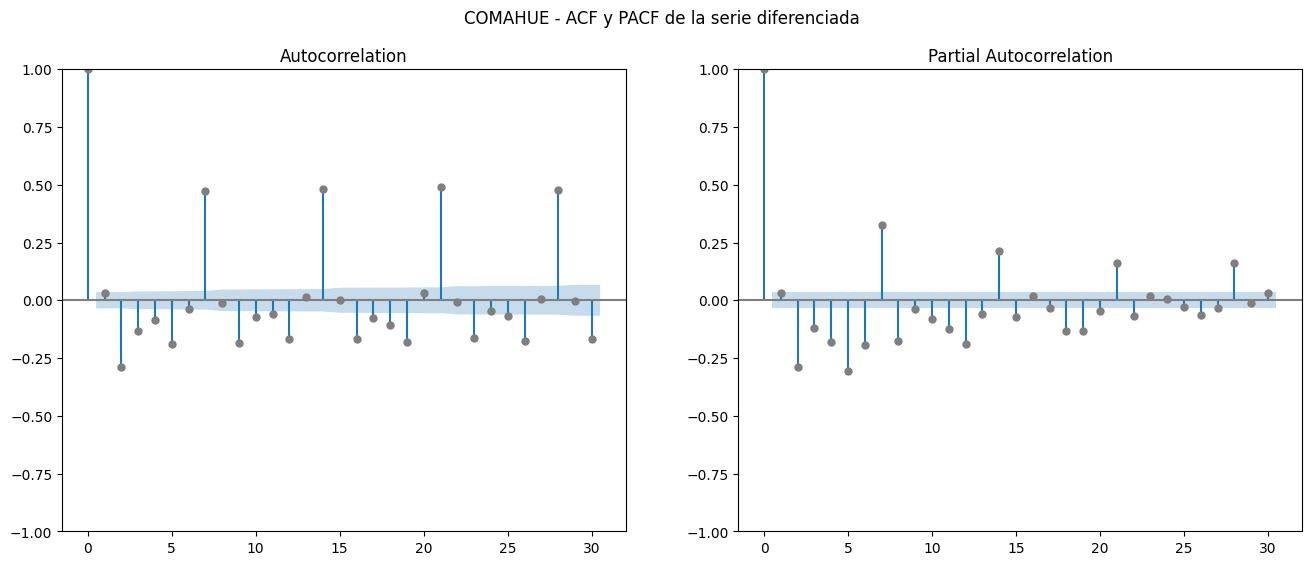

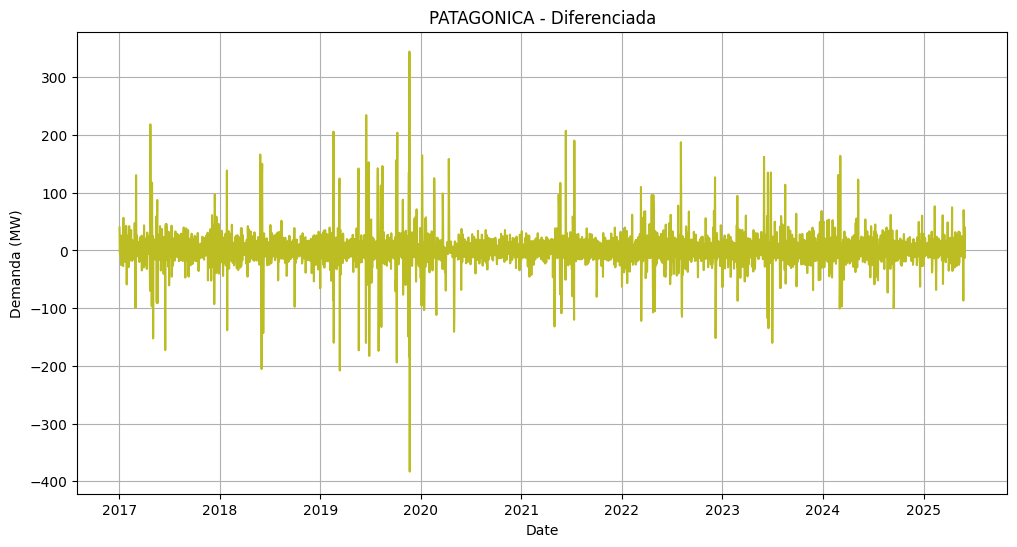

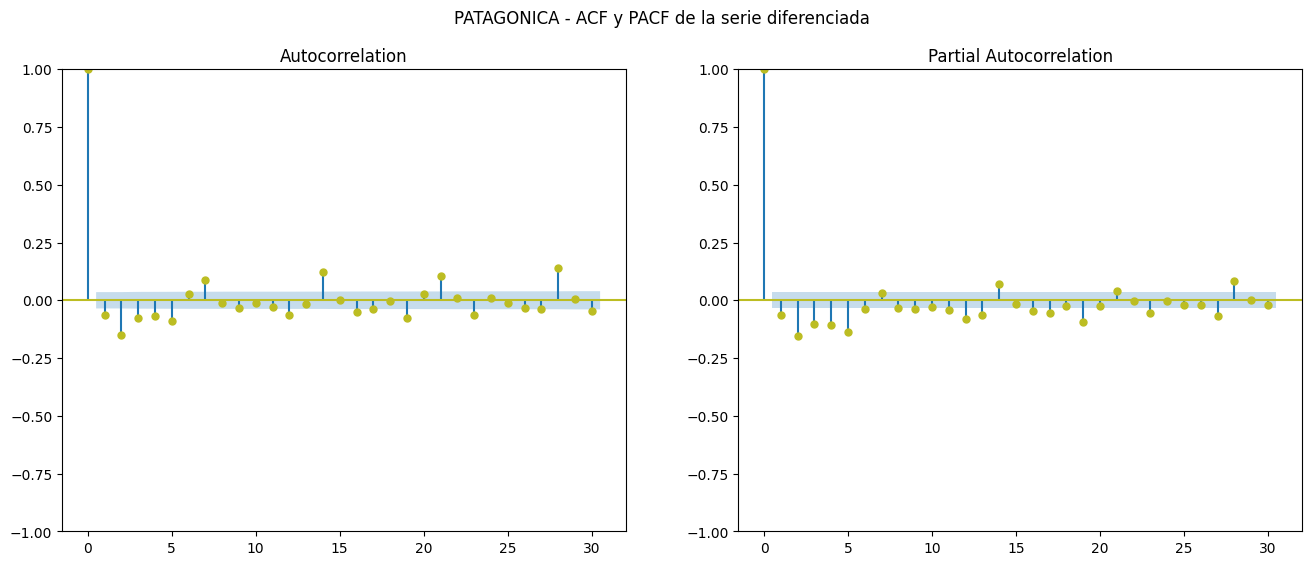

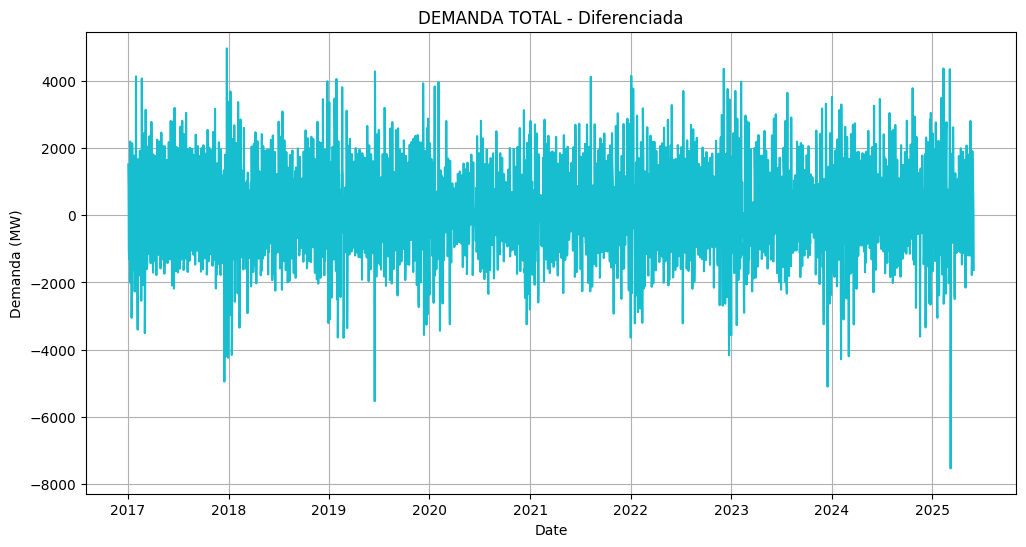

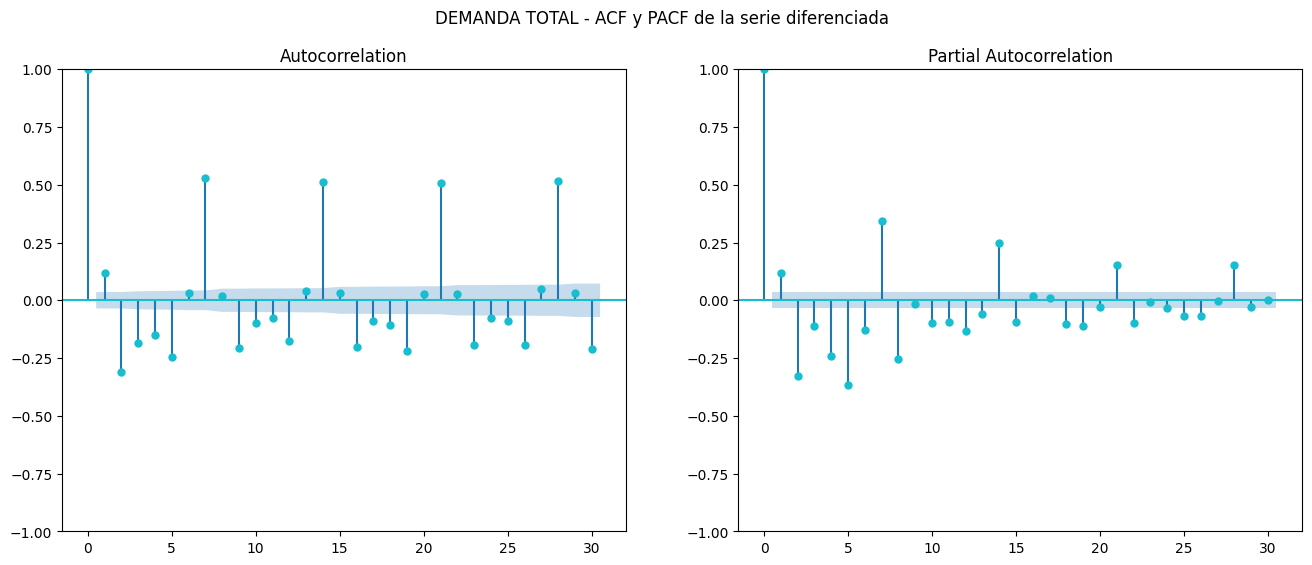

In [14]:
for col, serie in series.items():
    plot_series(serie['DIFF'], color=colores[col], title=f"{col} - Diferenciada", ymin=serie['DIFF'].min() * 1.1, ymax=serie['DIFF'].max() * 1.1)
    # plot_acf_pacf(serie['ORIGINAL'], lags=30, title=f"{col} - ACF y PACF de la serie original")
    plot_acf_pacf(serie['DIFF'], color=colores[col], lags=30, title=f"{col} - ACF y PACF de la serie diferenciada")

### Clara autocorrelación cada 7 días en todas las regiones.

### Este dato nos sirve de parámetro para indicarle la estacionalidad a SARIMA.

# (S)ARIMA funciona mal
### no incorpora tendencias, prediciendo sólamente el valor medio

In [15]:
# for col, serie in series.items():
#     serie['TRAIN'], serie['TEST'] = train_test_split(serie['ORIGINAL'], test_size=0.3)
#     # serie['FITTED'] = fit_arima(serie['TRAIN'], order=(5, 1, 3))
#     serie['FITTED'] = fit_sarima(serie['TRAIN'], order=(5, 1, 0), seasonal_order=(2, 0, 0, 7))
#     serie['FORECAST_SARIMA'], serie['CONF_INT_SARIMA'] = forecast_arima(serie['FITTED'], start=serie['TEST'].index[0], steps=len(serie['TEST']), periods=len(serie['TEST']))
#     plot_arima_forecast(serie['TRAIN'], 
#                         serie['TEST'], 
#                         serie['FORECAST_SARIMA'], 
#                         serie['CONF_INT_SARIMA'], 
#                         title=f"{col} - SARIMA",
#                         ymin=0,
#                         ymax=max(max(serie['FORECAST_SARIMA']),max(serie['ORIGINAL']))*1.1
#                         )

# Descomposición Tendencia + Estacionalidad + Residuo

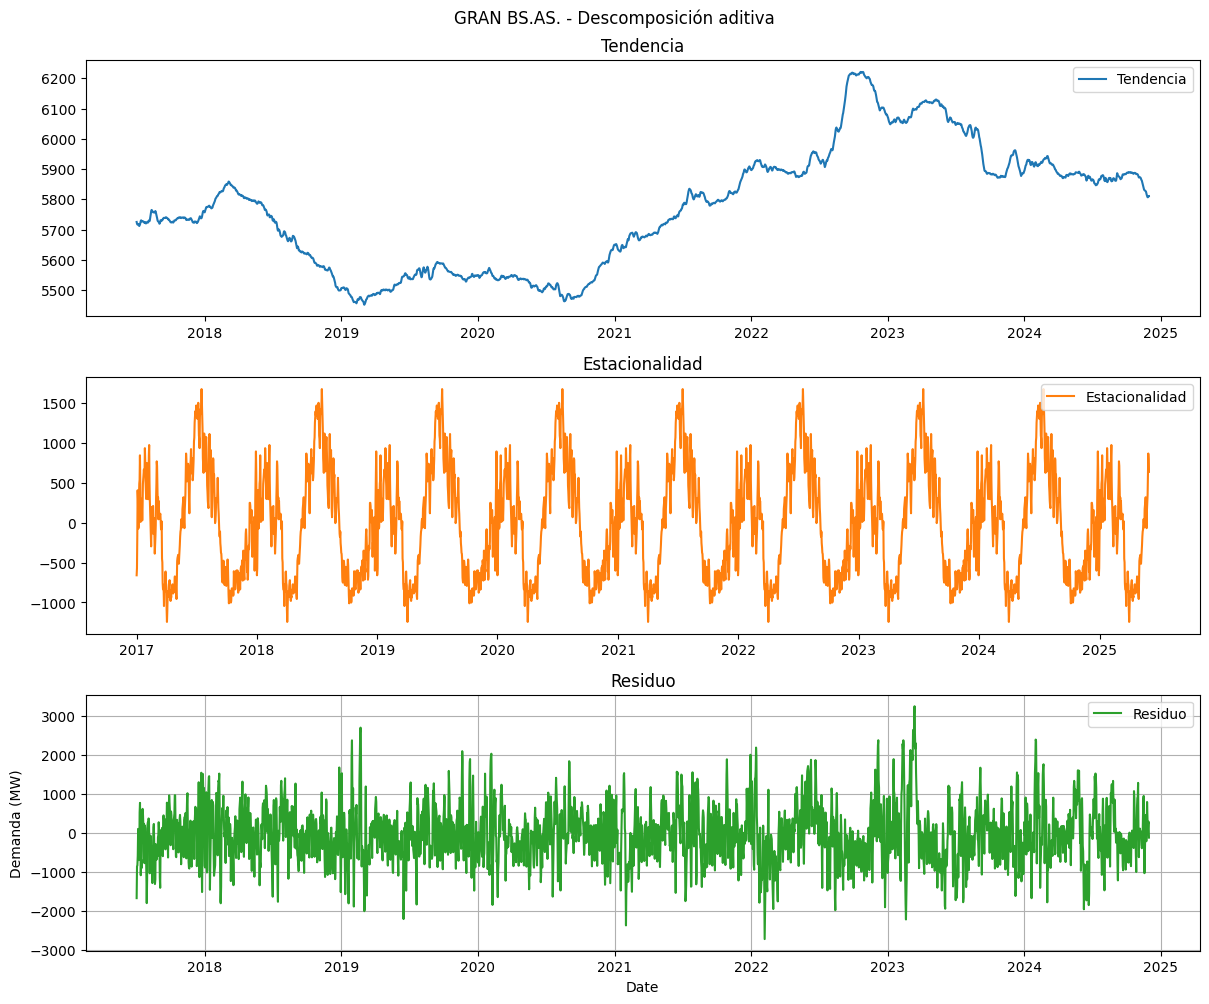

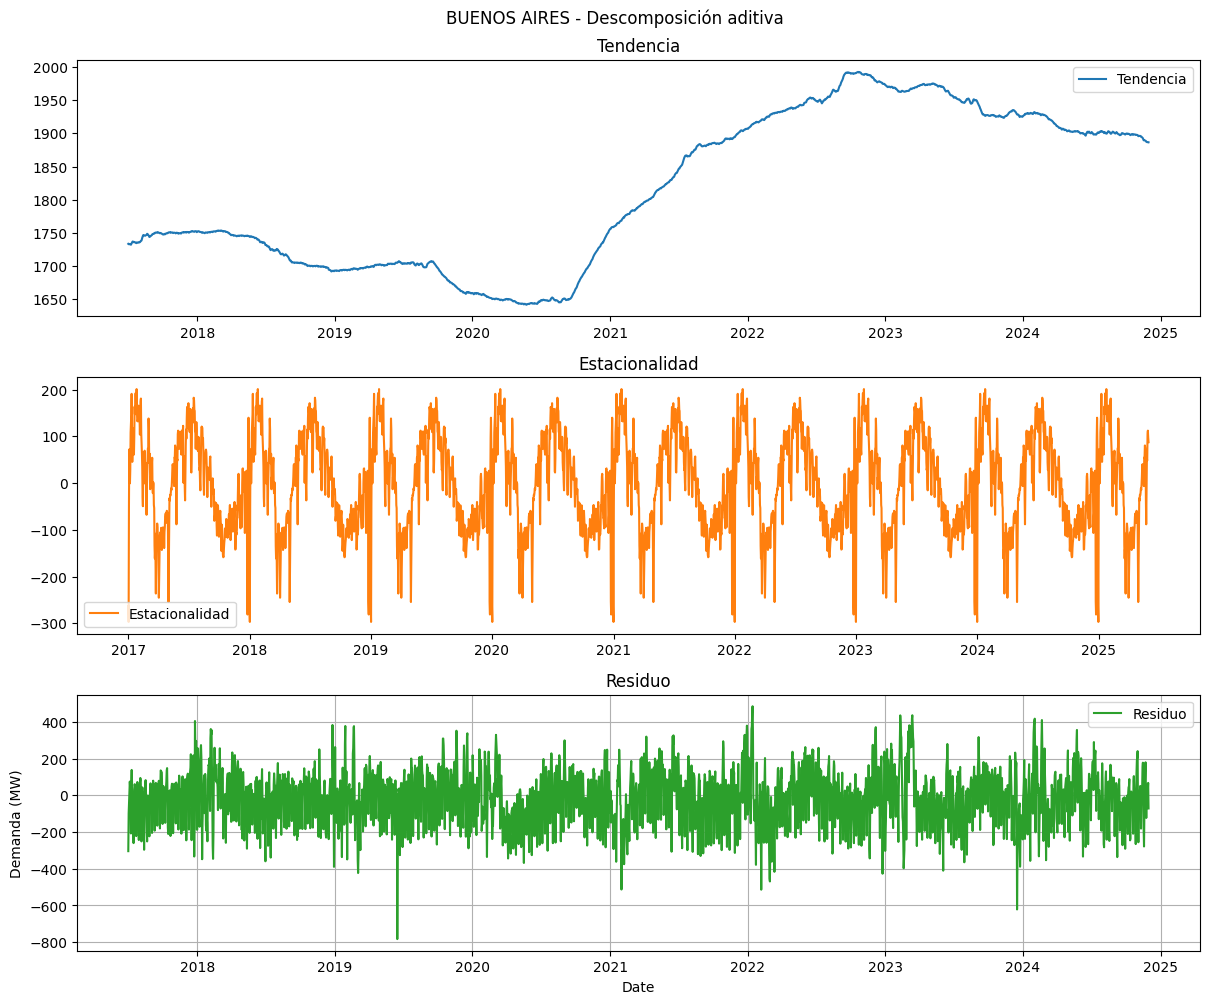

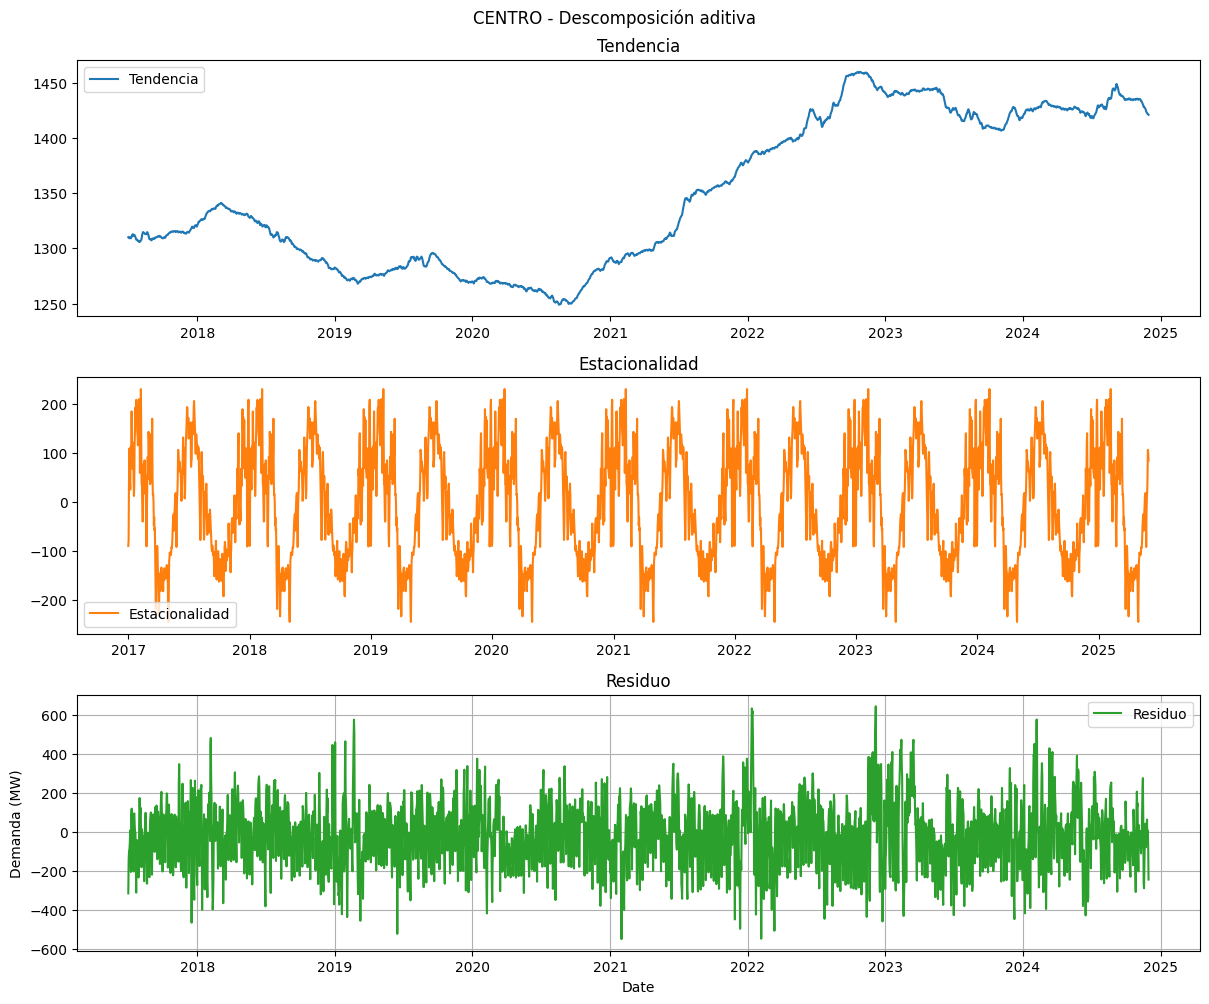

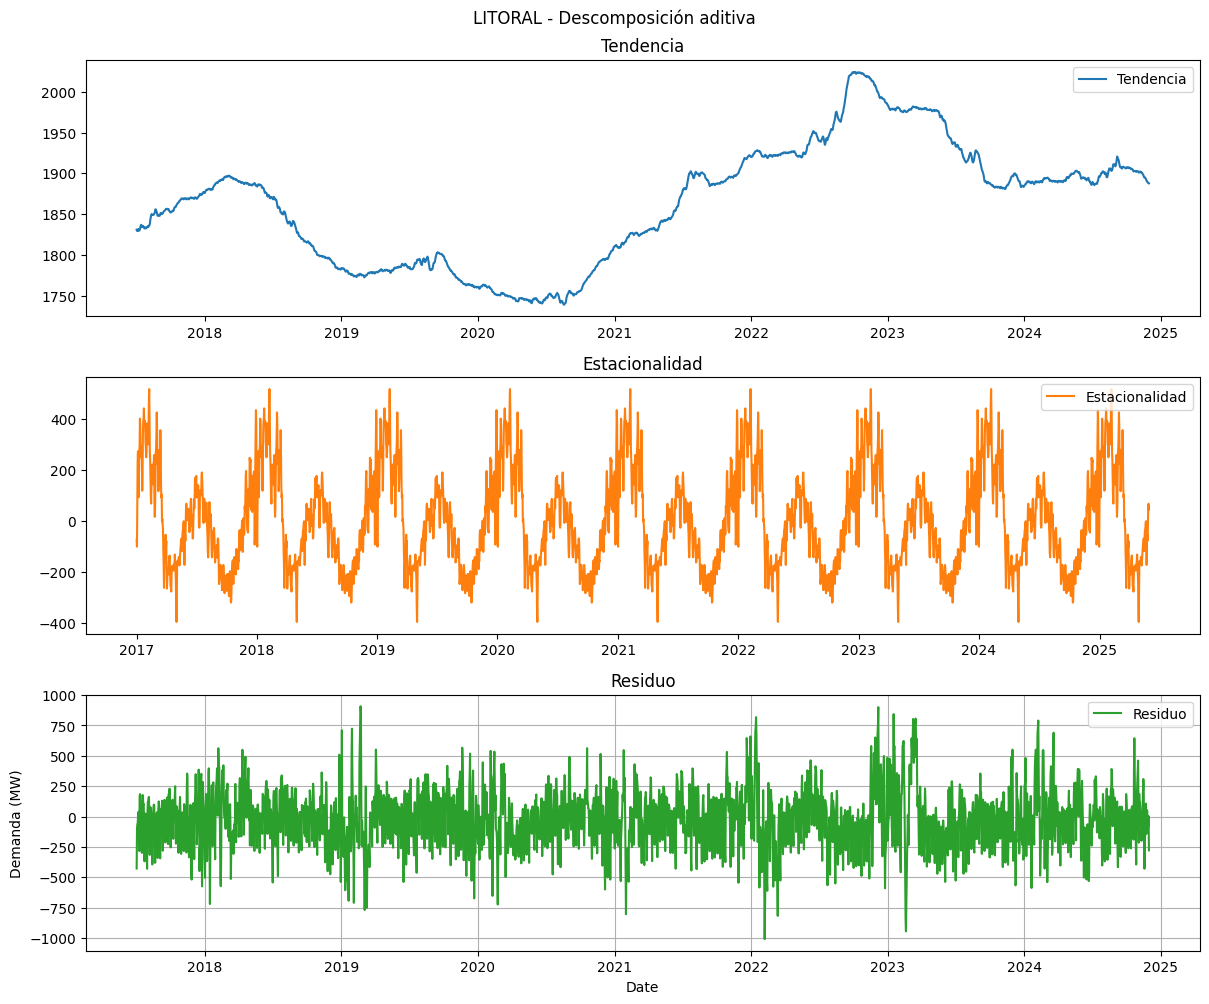

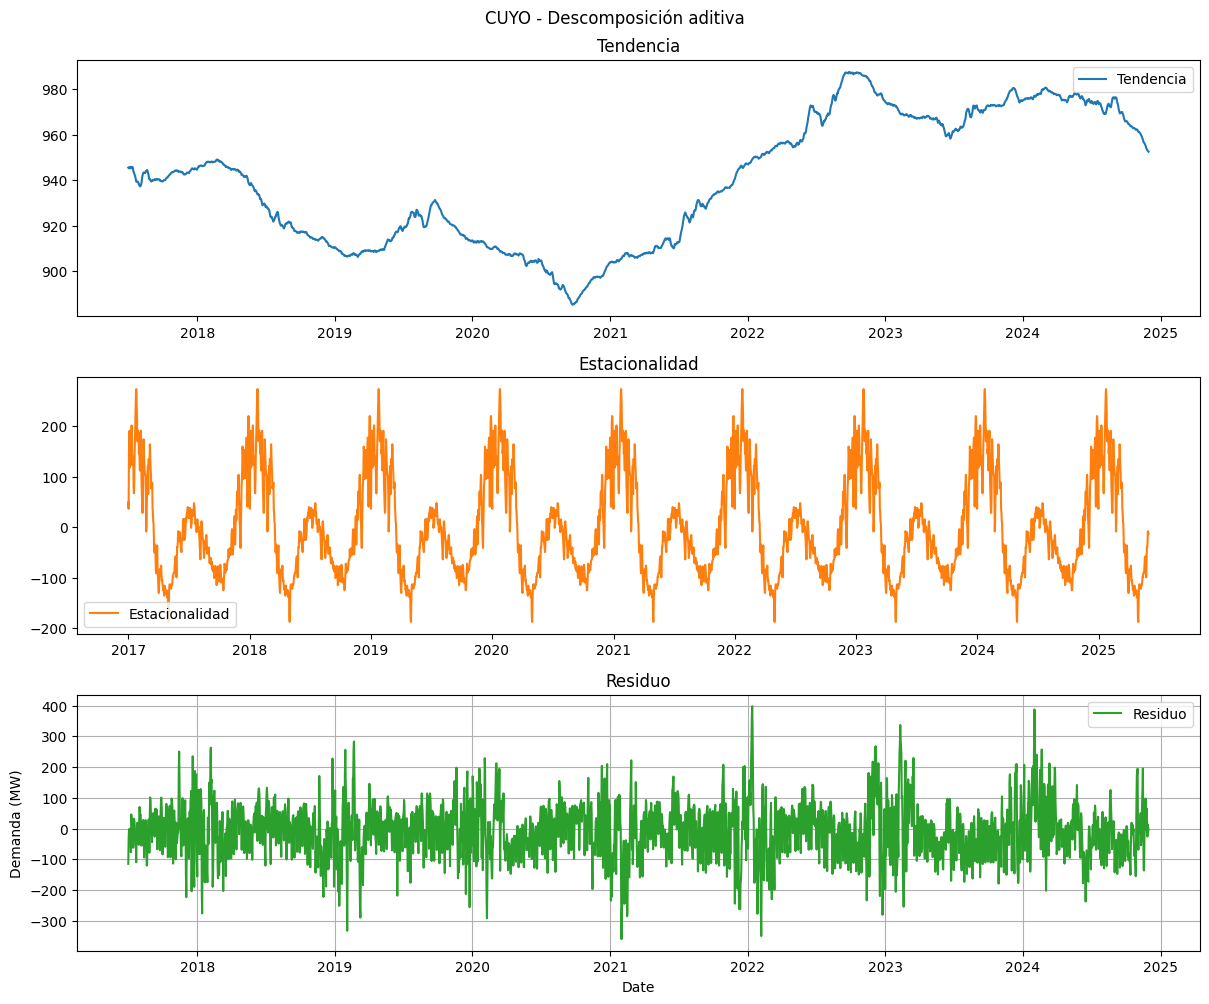

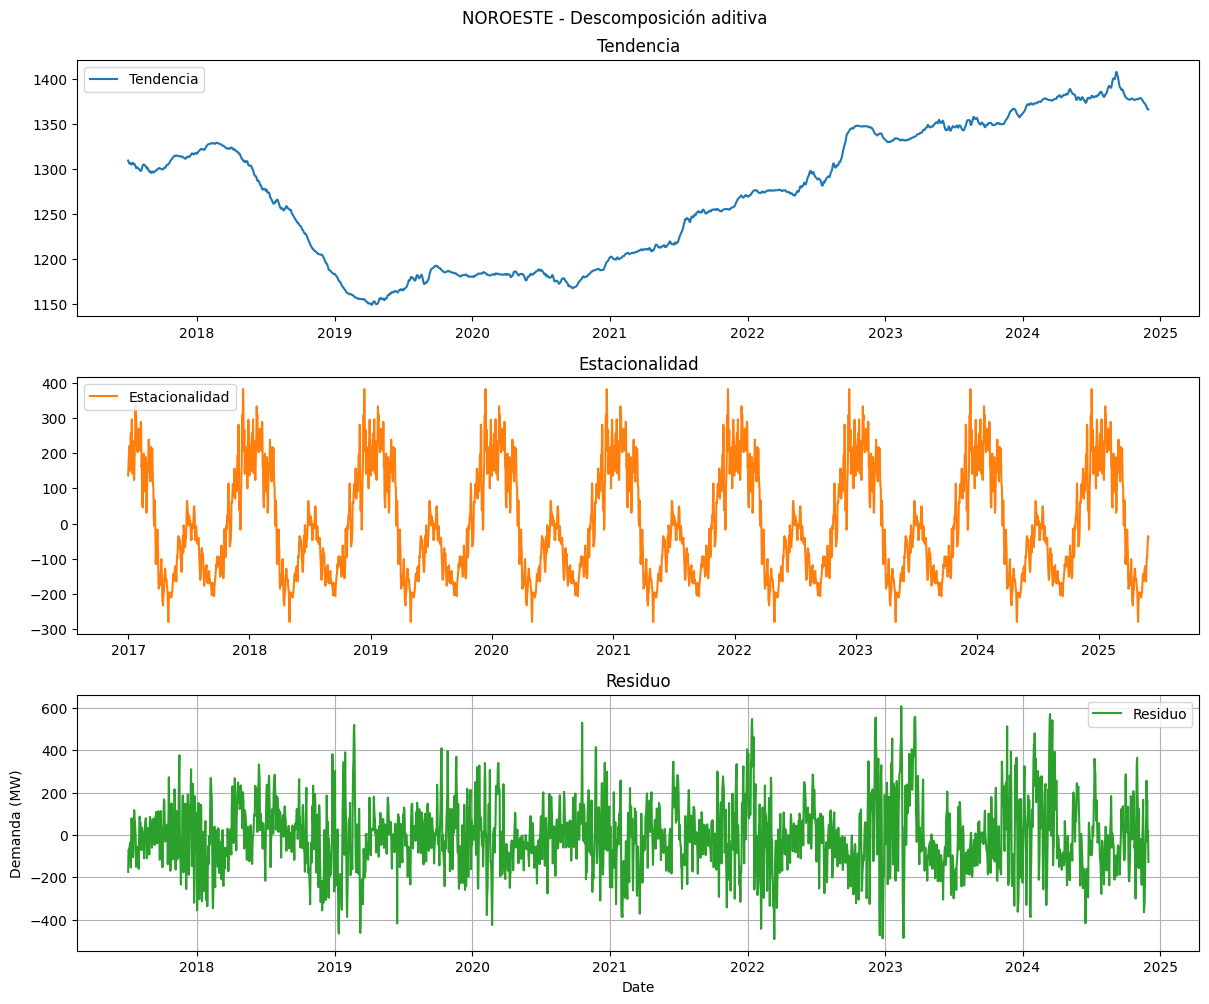

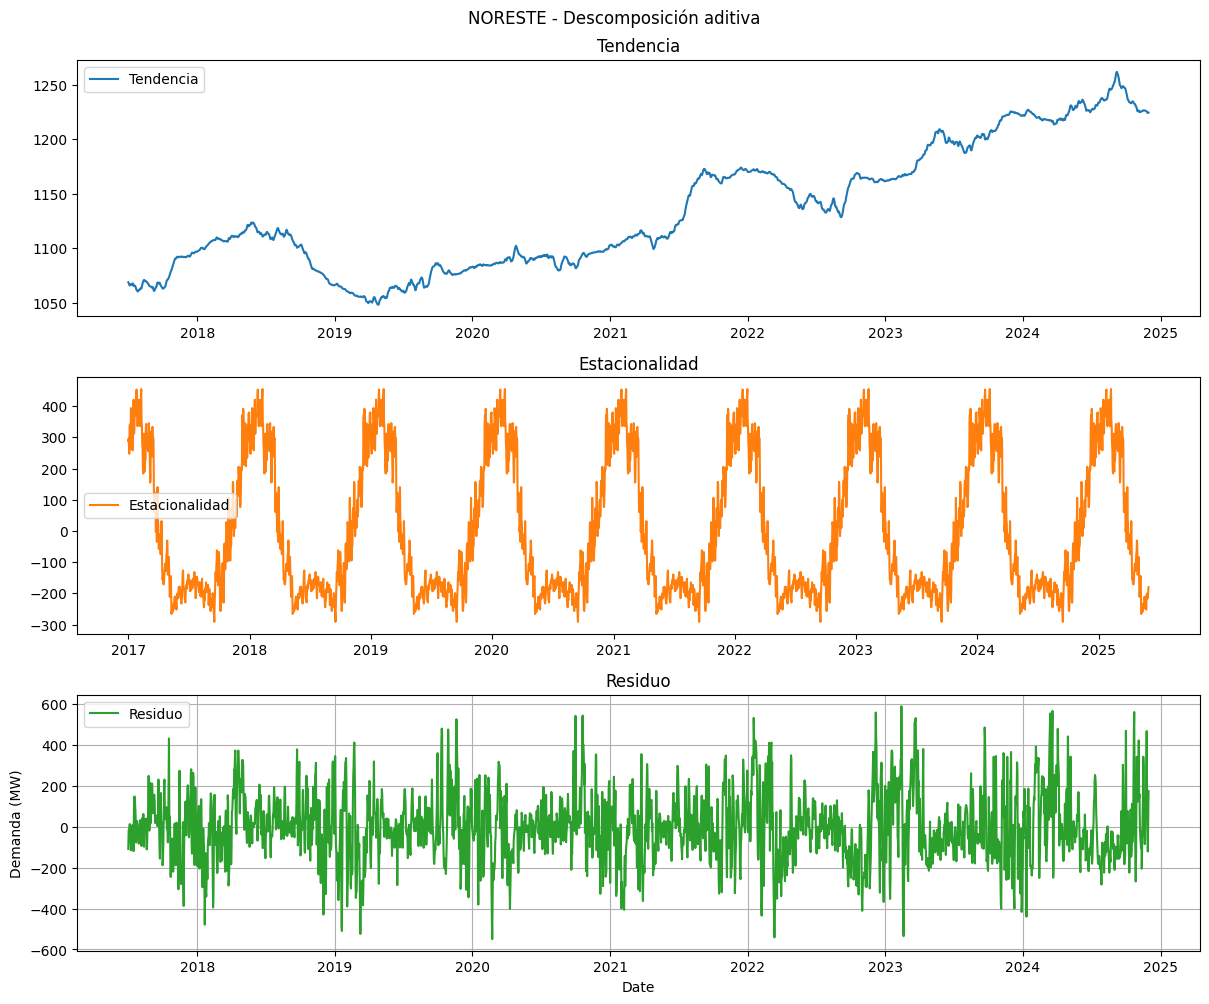

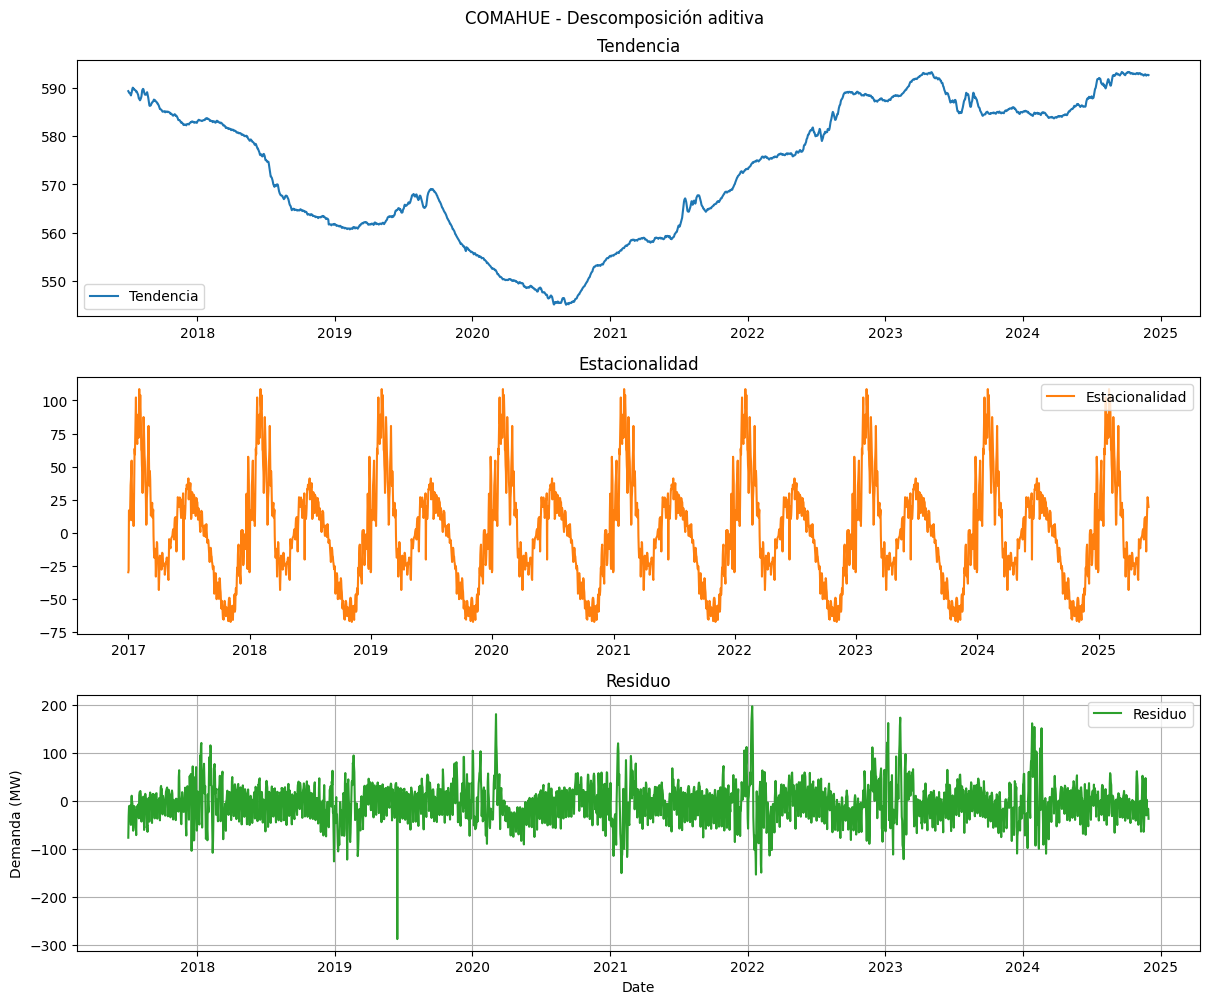

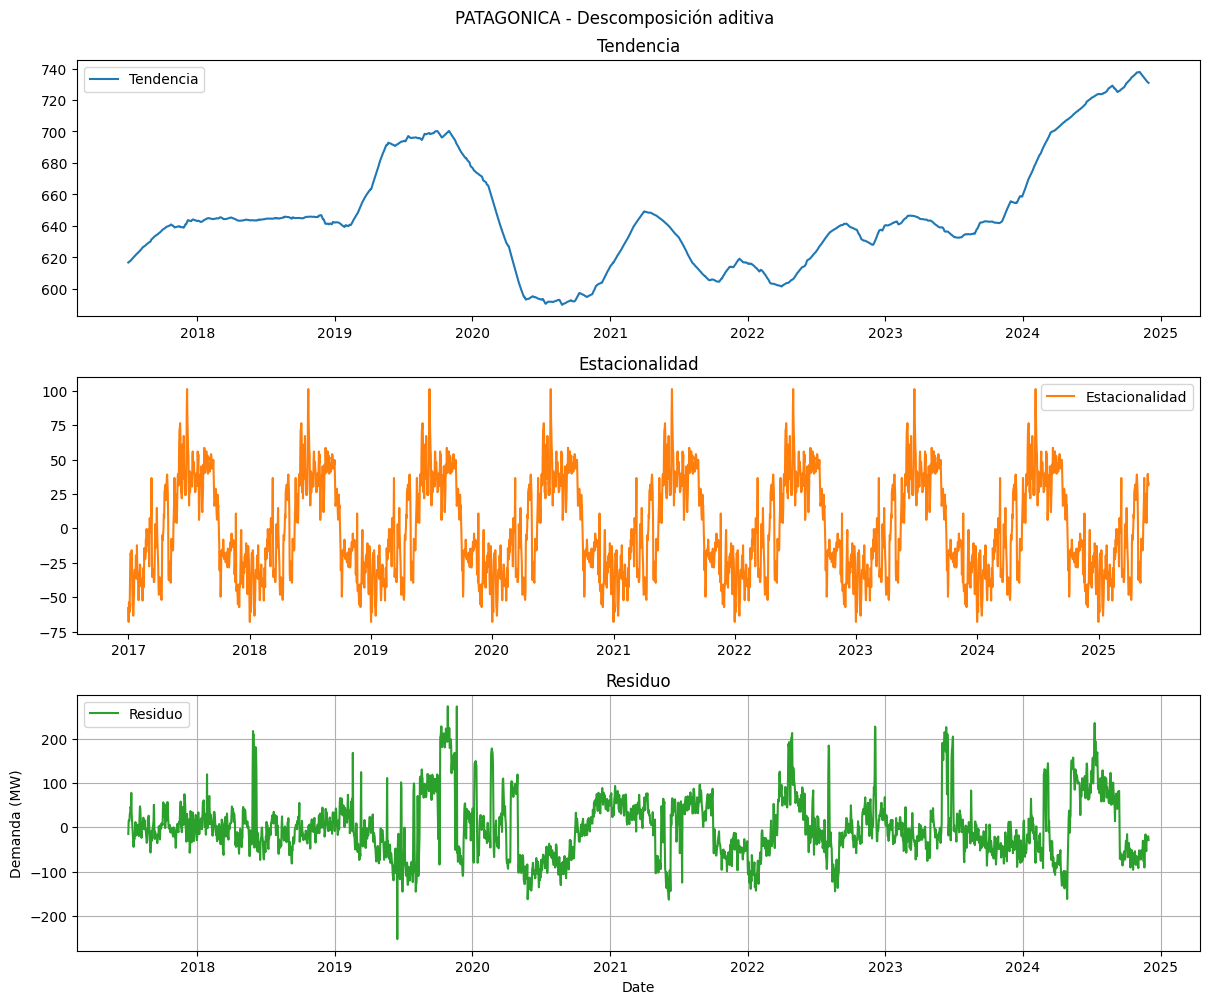

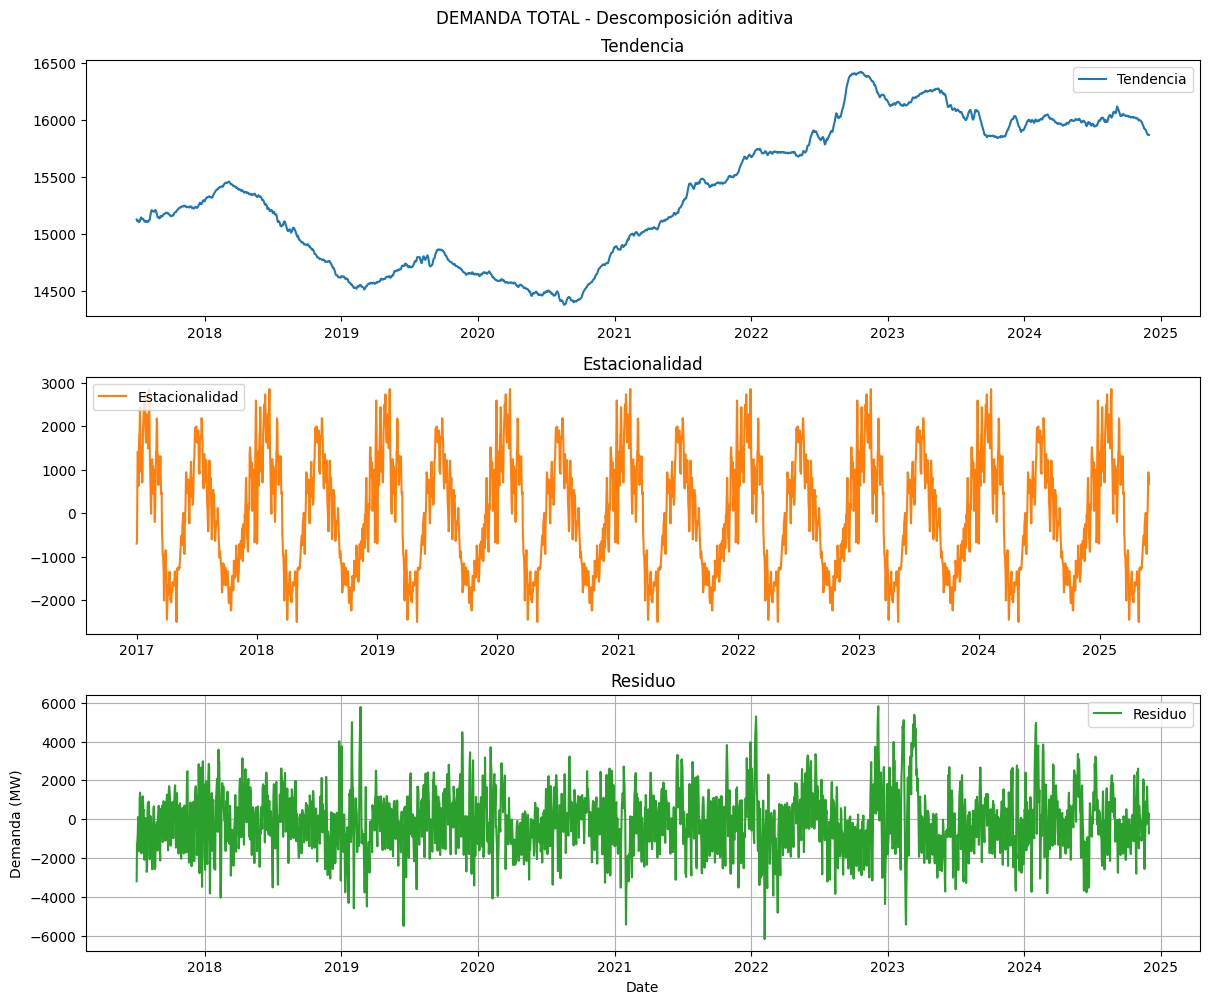

In [16]:
for col, serie in series.items():
    serie['DECOMPOSED'] = decompose_series(serie['ORIGINAL'], model='additive', period=365)
    plot_decomposition_2(serie['DECOMPOSED'], title=f"{col} - Descomposición aditiva")

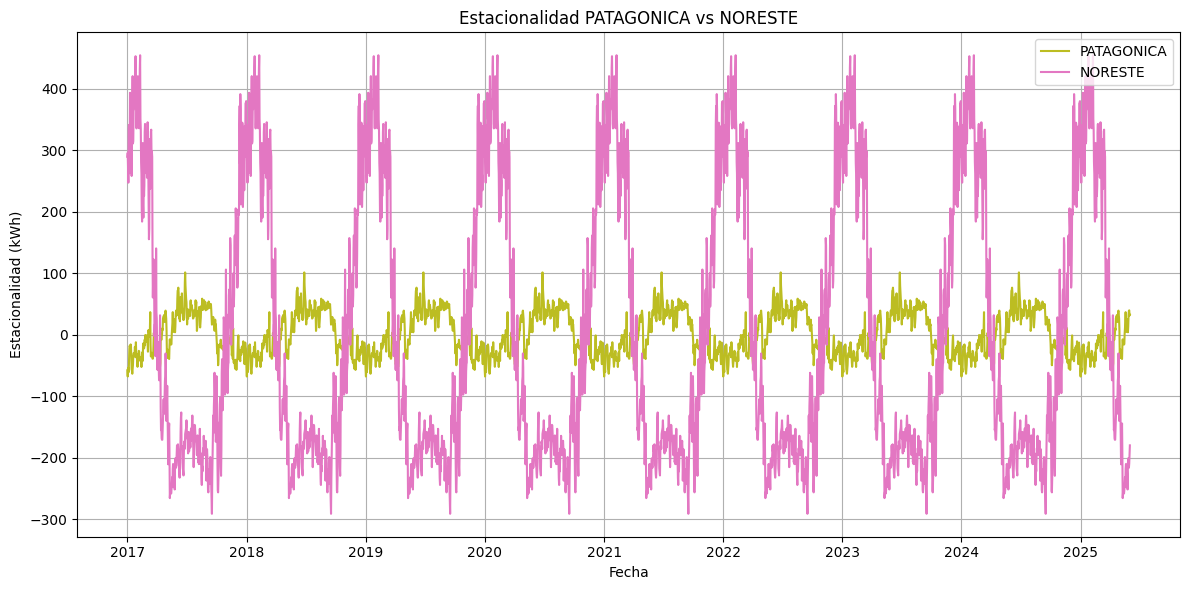

In [17]:
# Breve análisis de estacionalidad PATAGONIA - NORESTE

try:
    patag = series['PATAGONICA']['DECOMPOSED'].seasonal.dropna()
    noreste = series['NORESTE']['DECOMPOSED'].seasonal.dropna()
    plt.figure(figsize=(12, 6))
    plt.plot(patag, color=colores['PATAGONICA'], label='PATAGONICA')
    plt.plot(noreste, color=colores['NORESTE'], label='NORESTE')
    plt.title('Estacionalidad PATAGONICA vs NORESTE')
    plt.xlabel('Fecha')
    plt.ylabel('Estacionalidad (kWh)')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig('img/estacionalidad_patag_vs_noreste.png', dpi=300, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Error al comparar estacionalidad PATAGONIA - NORESTE: {e}")

# Prophet
### Utilizamos prophet sobre la serie MA30 de cada región.
### Podemos también utilizar la serie orignial.

In [18]:
# Ajustamos el modelo Prophet para cada serie, 70% entrenamiento y 30% test
for col, serie in series.items():
    serie['TRAIN'], serie['TEST'] = train_test_split(serie['MA30'], test_size=0.3)
    serie['PROPHET_MODEL'] = fit_prophet(serie['TRAIN'])
    serie['FORECAST_PROPHET'] = forecast_prophet(serie['PROPHET_MODEL'], periods=len(serie['TEST']), freq='D')
    serie['FORECAST_PROPHET_TRAIN'], serie['FORECAST_PROPHET_TEST'] = train_test_split(serie['FORECAST_PROPHET'], test_size=0.3)

00:39:51 - cmdstanpy - INFO - Chain [1] start processing
00:39:52 - cmdstanpy - INFO - Chain [1] done processing
00:39:52 - cmdstanpy - INFO - Chain [1] start processing
00:39:54 - cmdstanpy - INFO - Chain [1] done processing
00:39:54 - cmdstanpy - INFO - Chain [1] start processing
00:39:55 - cmdstanpy - INFO - Chain [1] done processing
00:39:55 - cmdstanpy - INFO - Chain [1] start processing
00:39:56 - cmdstanpy - INFO - Chain [1] done processing
00:39:57 - cmdstanpy - INFO - Chain [1] start processing
00:39:58 - cmdstanpy - INFO - Chain [1] done processing
00:39:58 - cmdstanpy - INFO - Chain [1] start processing
00:39:59 - cmdstanpy - INFO - Chain [1] done processing
00:40:00 - cmdstanpy - INFO - Chain [1] start processing
00:40:00 - cmdstanpy - INFO - Chain [1] done processing
00:40:01 - cmdstanpy - INFO - Chain [1] start processing
00:40:02 - cmdstanpy - INFO - Chain [1] done processing
00:40:02 - cmdstanpy - INFO - Chain [1] start processing
00:40:03 - cmdstanpy - INFO - Chain [1]

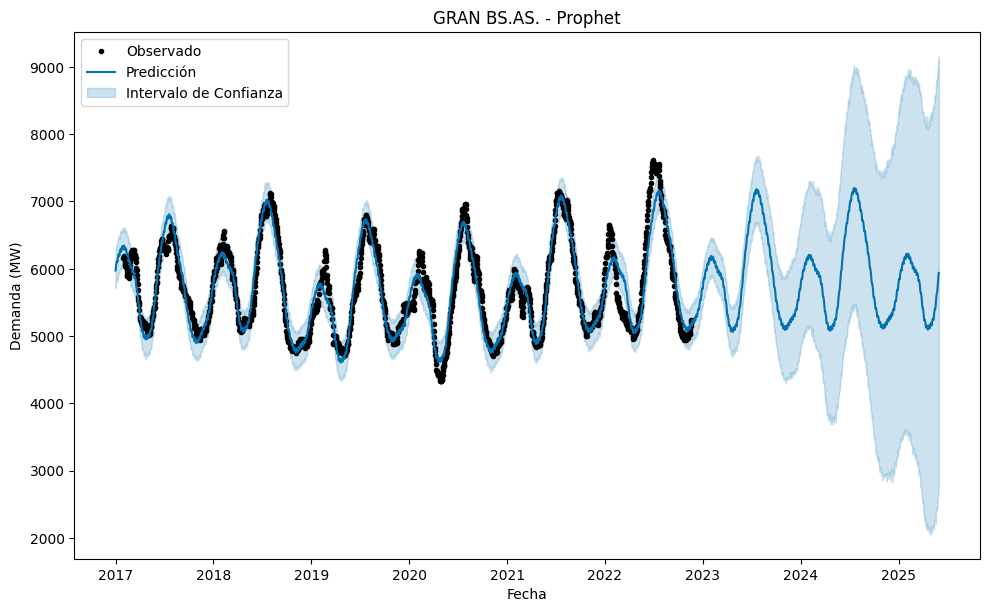

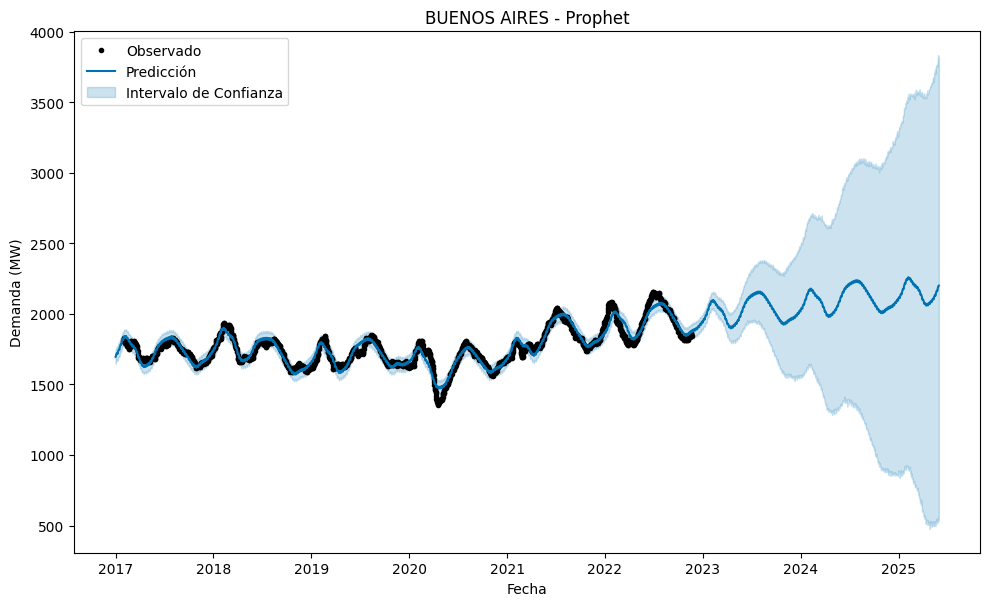

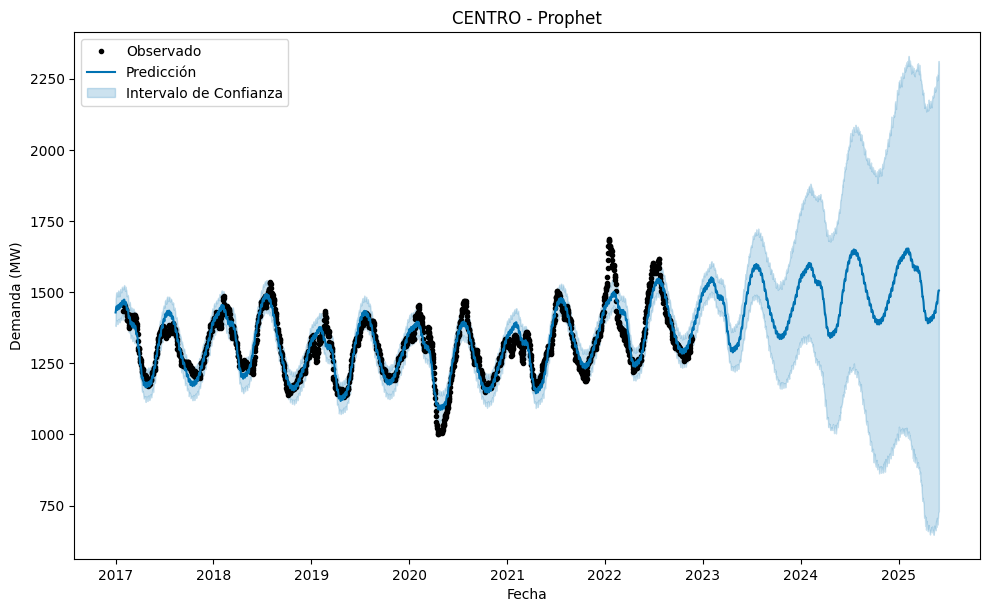

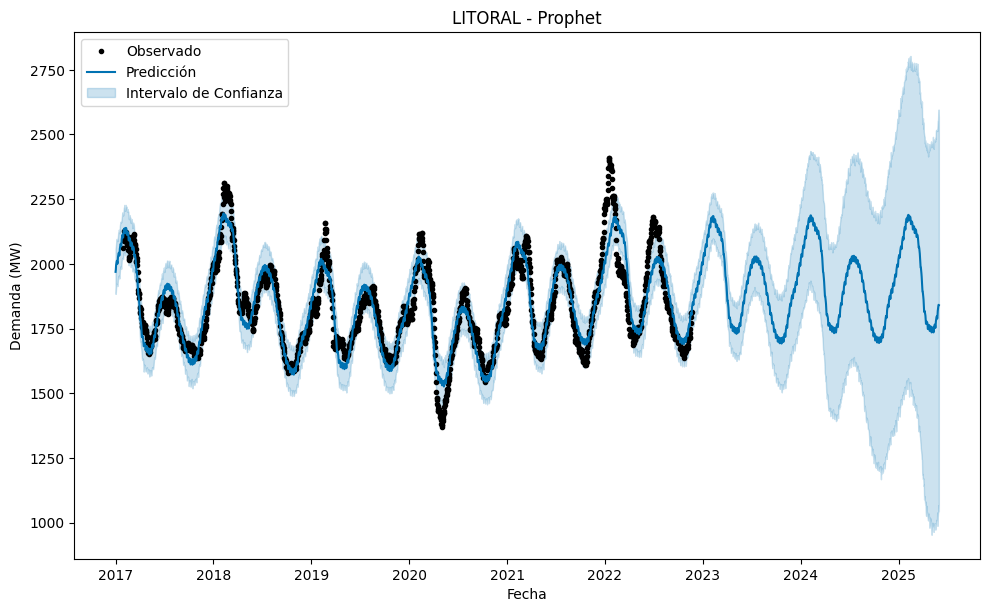

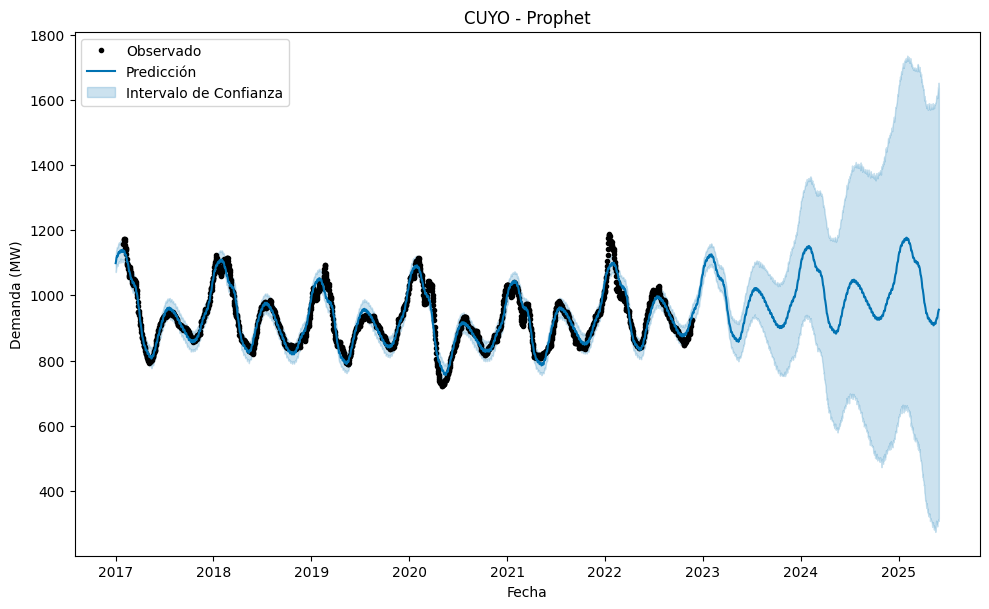

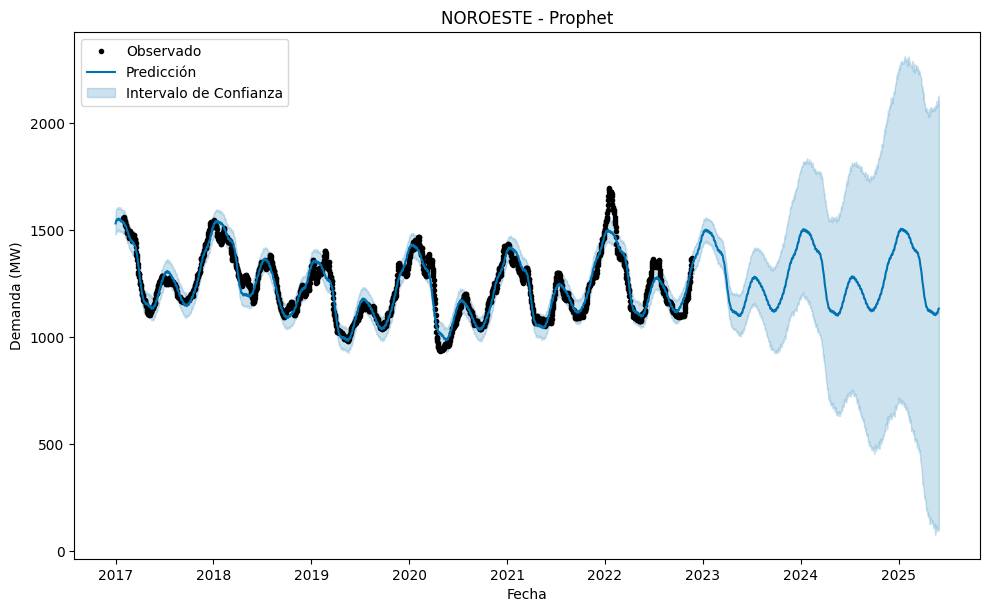

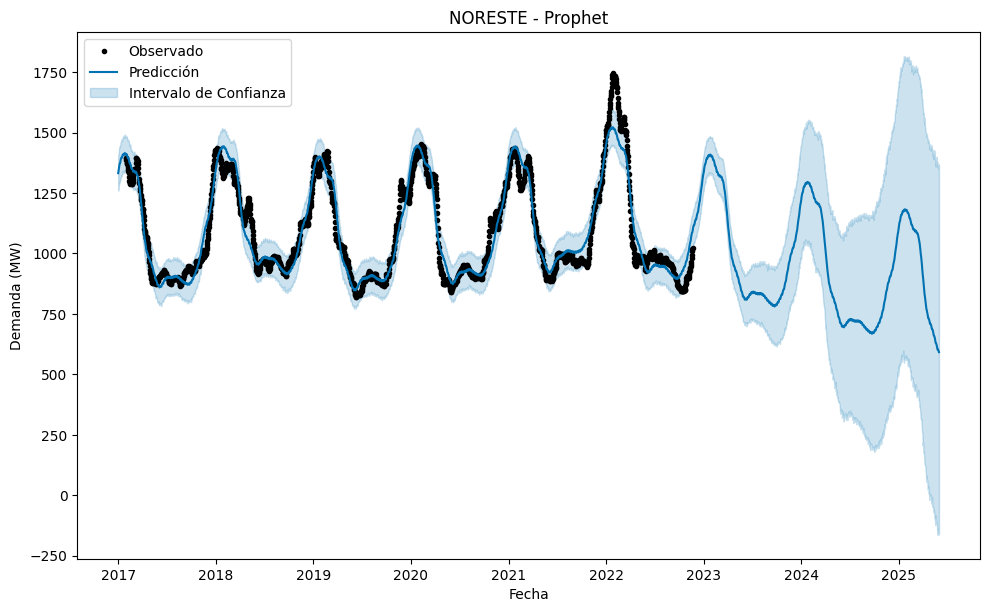

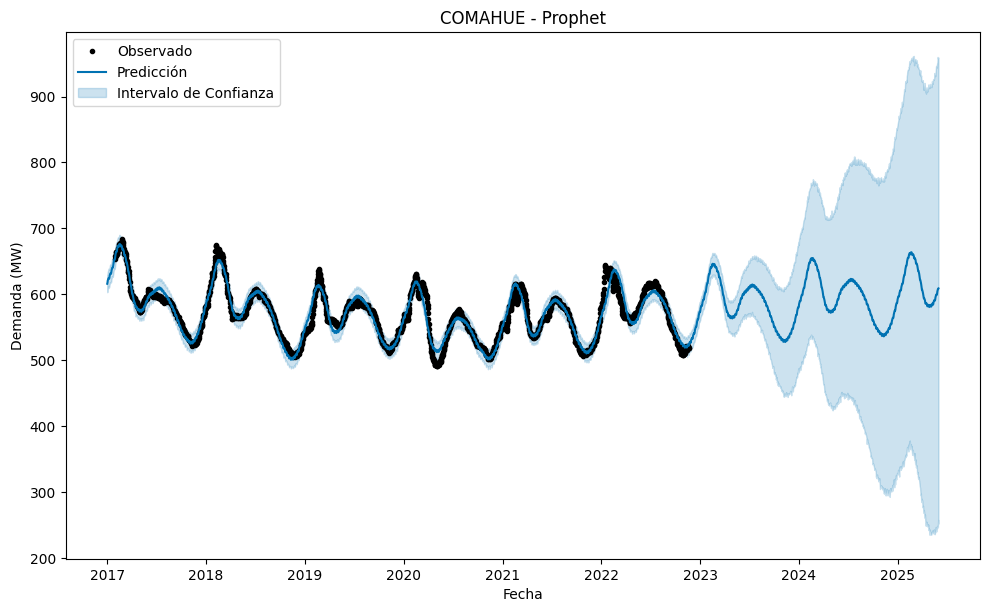

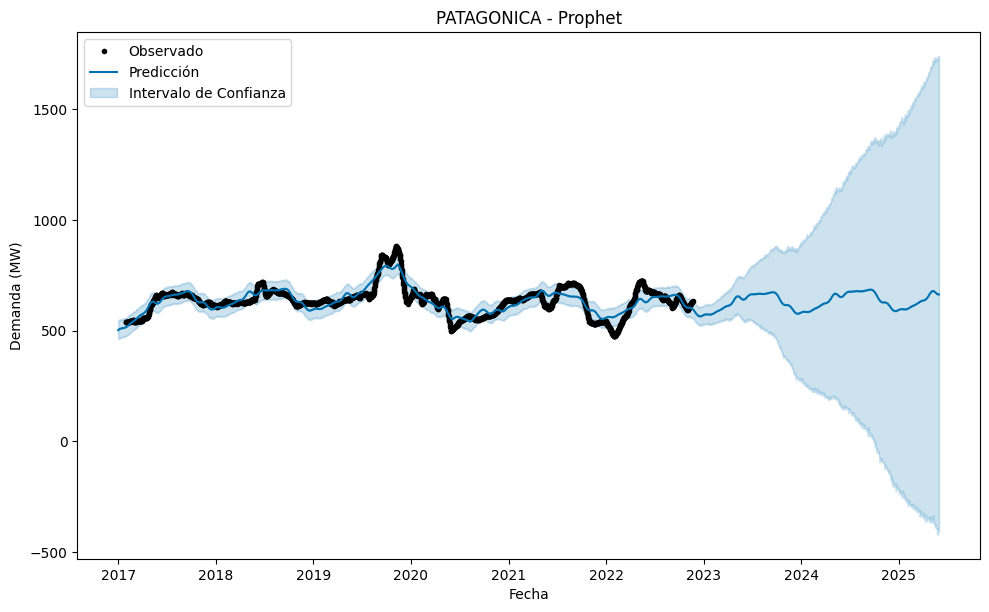

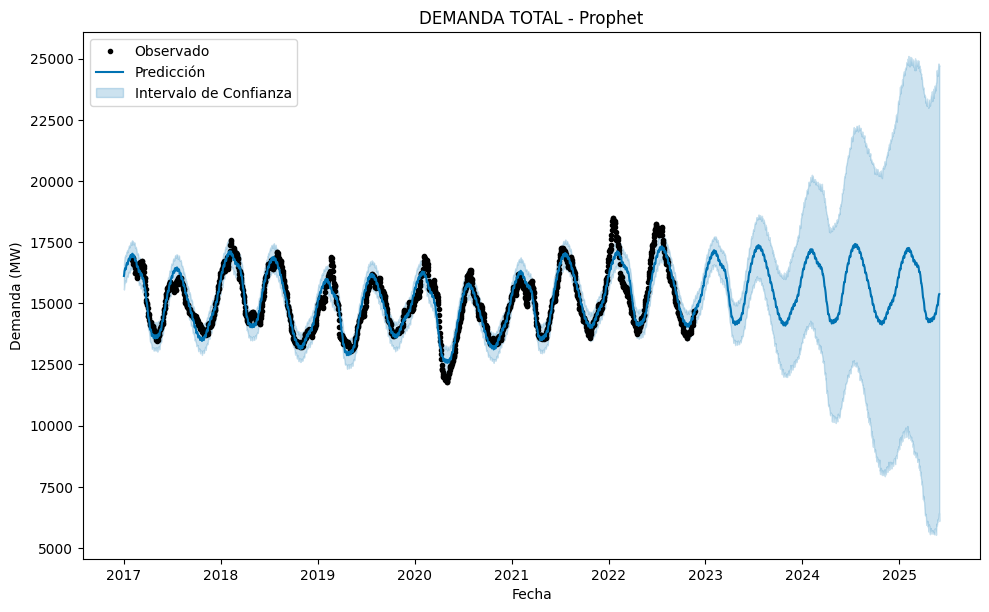

In [19]:
# Graficamos las predicciones de Prophet
for col, serie in series.items():
    plot_forecast_prophet(model=serie['PROPHET_MODEL'],
                          forecast=serie['FORECAST_PROPHET'],
                          title=f"{col} - Prophet")

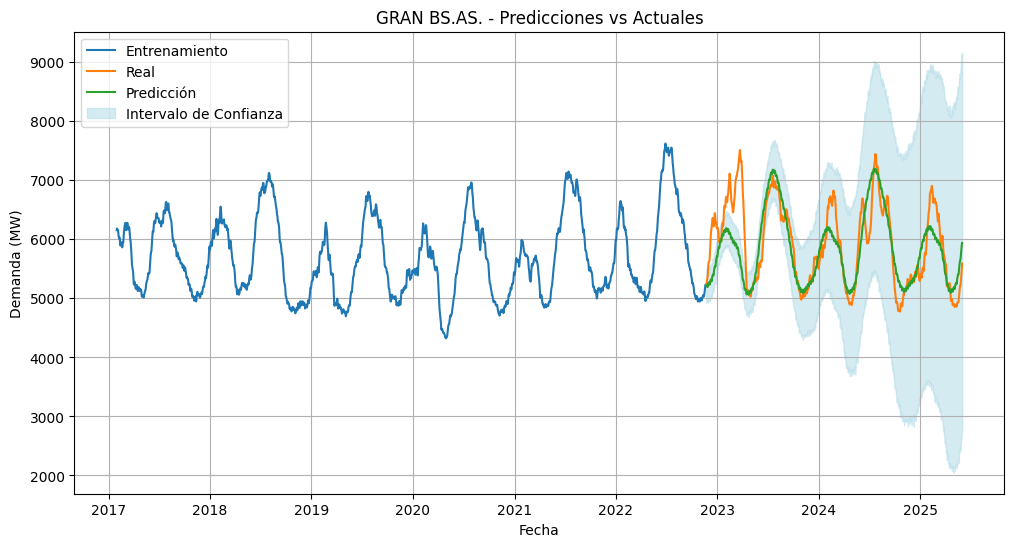

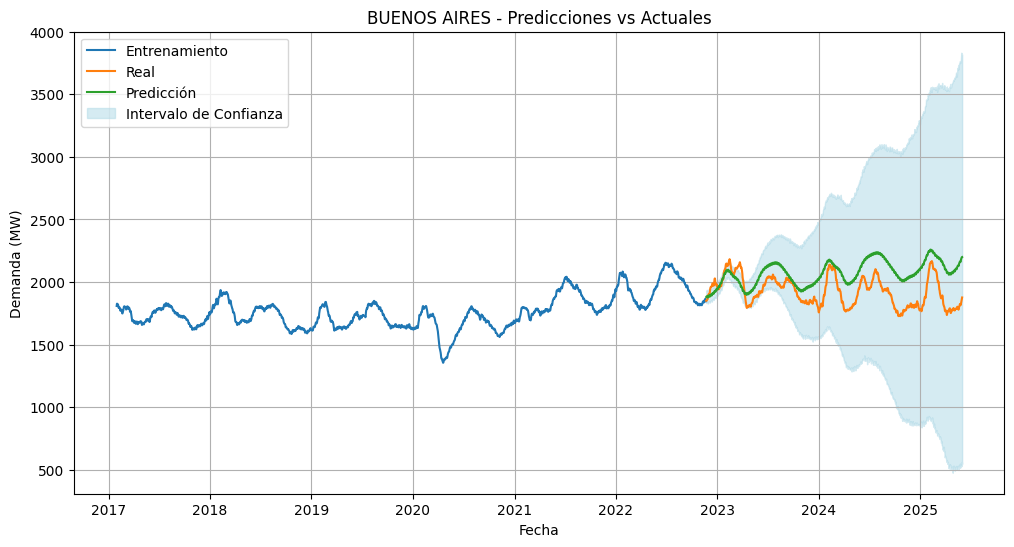

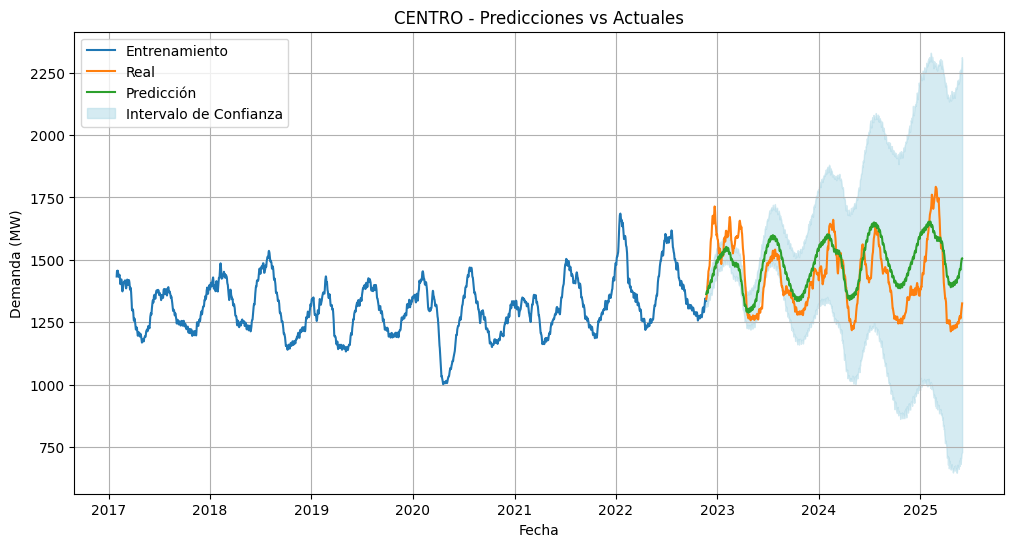

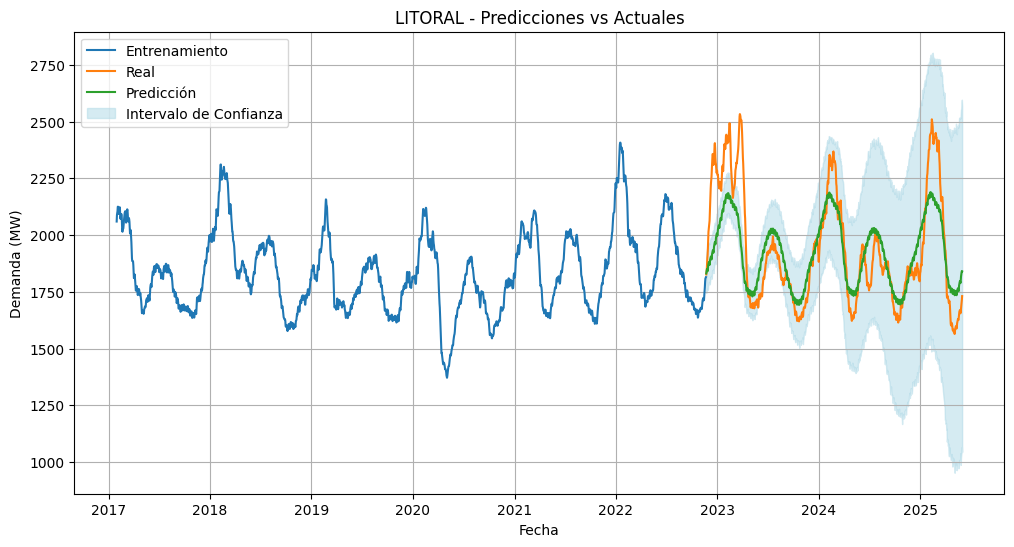

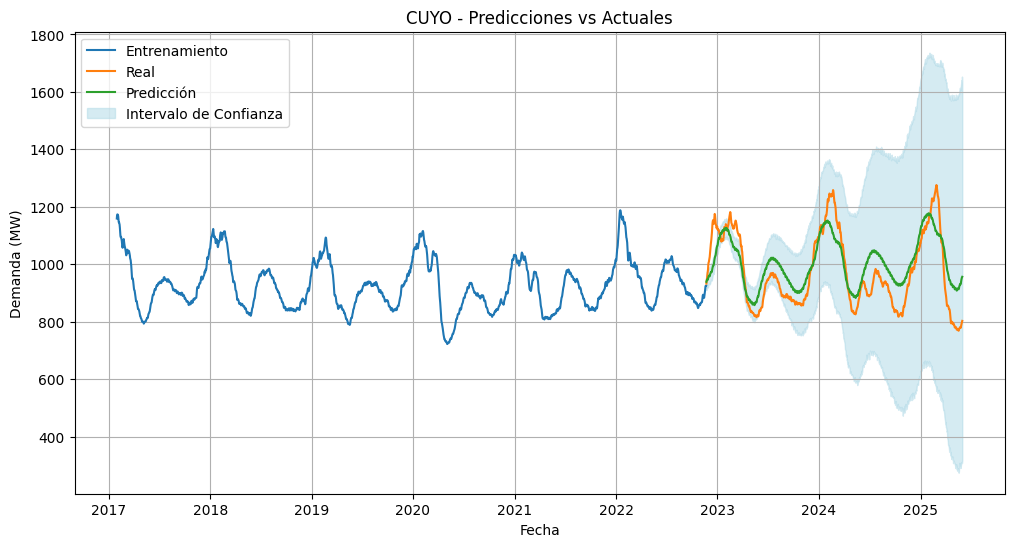

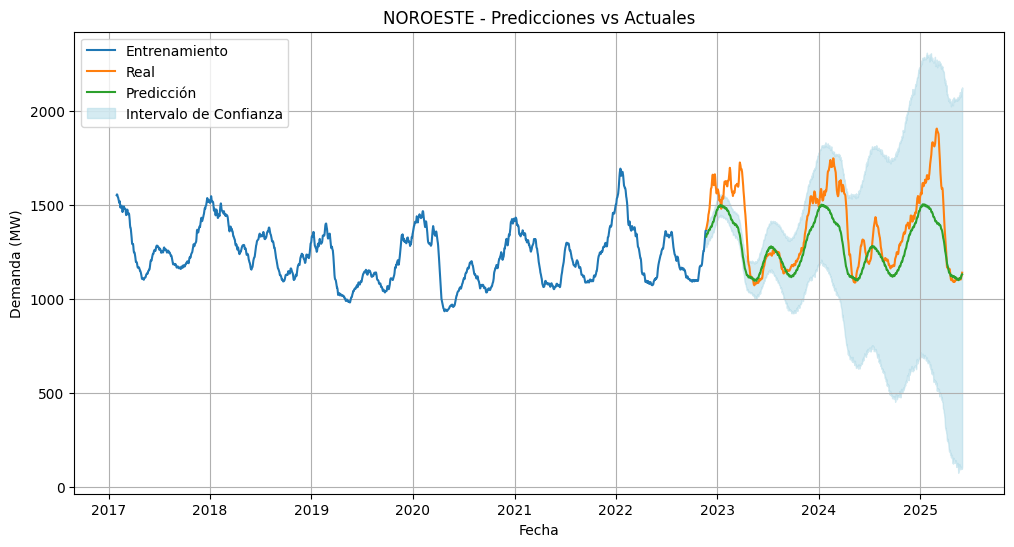

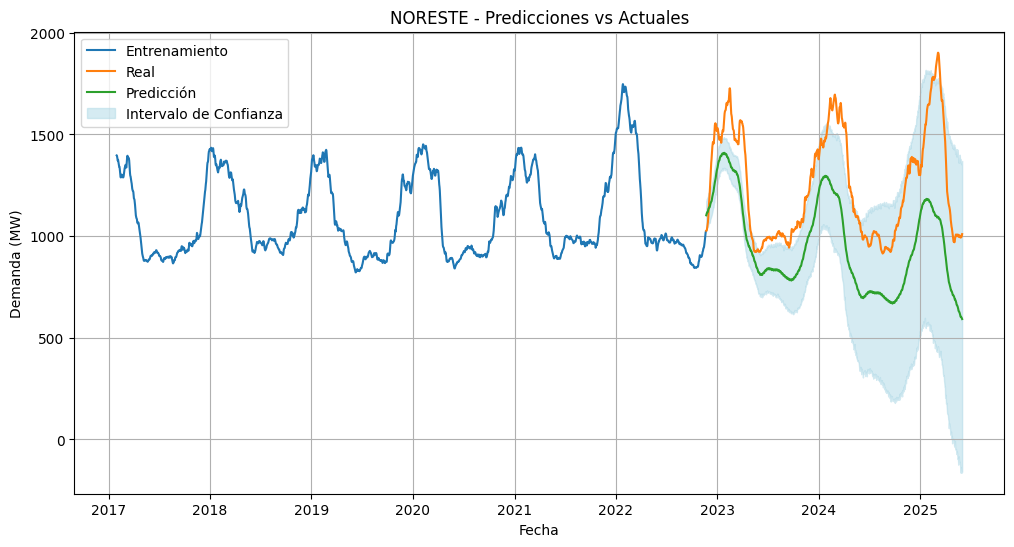

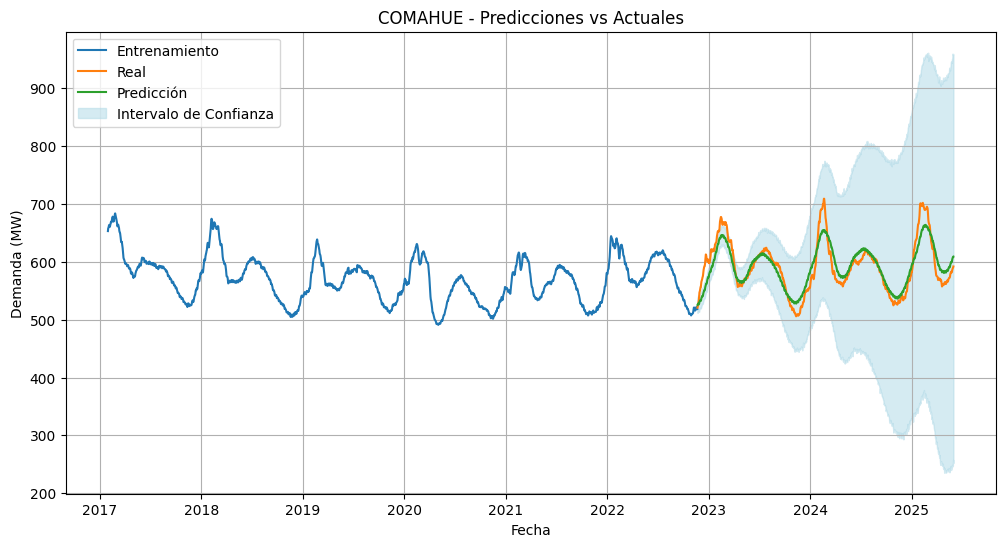

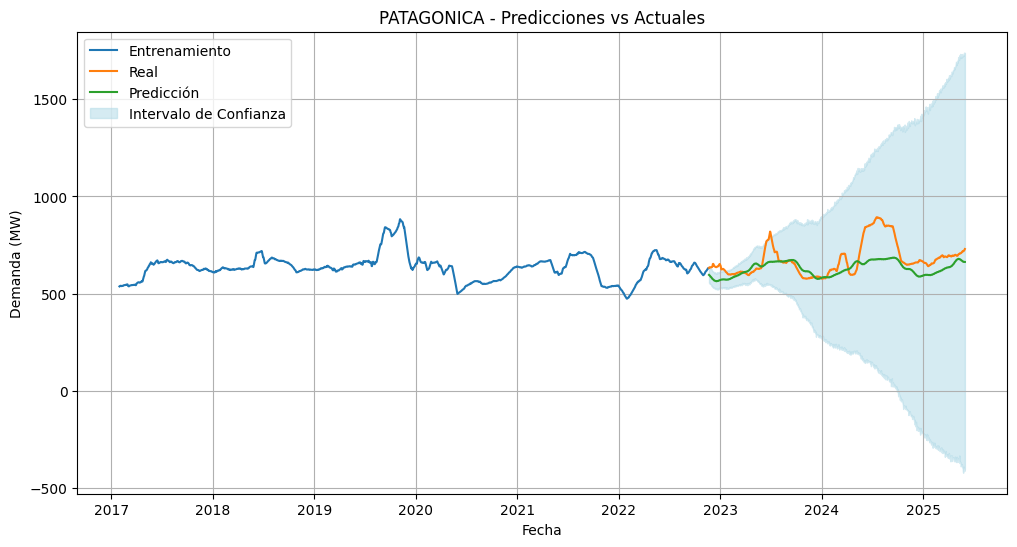

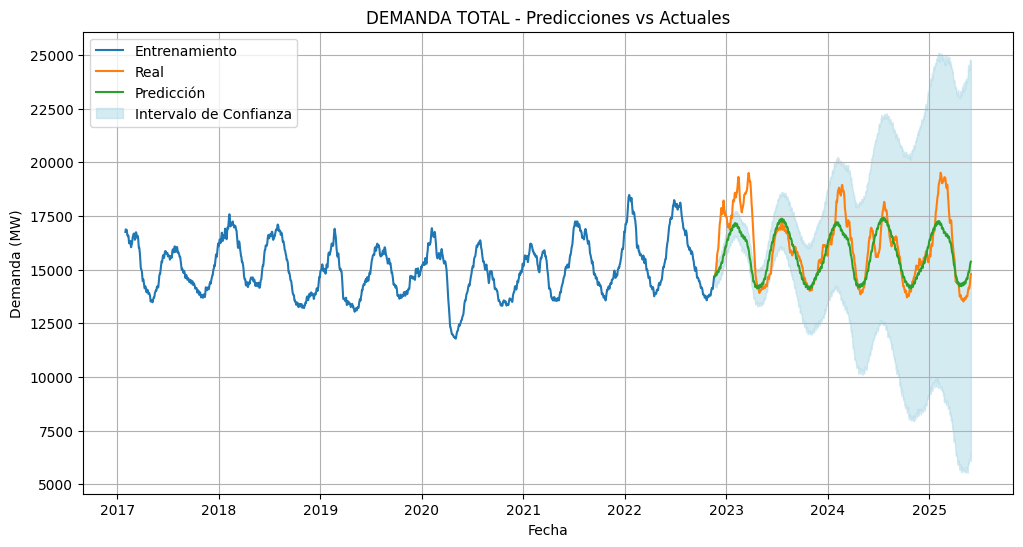

In [20]:
# Graficamos las predicciones de Prophet vs los valores reales
for col, serie in series.items():
    plot_prophet_predictions_vs_actuals(forecast=serie['FORECAST_PROPHET_TEST'], 
                                        actuals_train=serie['TRAIN'], 
                                        actuals_test=serie['TEST'],
                                        title=f"{col} - Predicciones vs Actuales", 
                                        xlabel='Fecha', 
                                        ylabel='Demanda (MW)'#, 
                                        # ymin=max(0, serie['MA30'].min() * 0.6), 
                                        # ymax=serie['MA30'].max() * 1.1
                                        )